In [1]:
#%autoreload
import pickle
import numpy as np
import pandas as pd
#import plotly.graph_objs as go
#import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
import matplotlib.colors as mcolors

from scipy import stats

#import seaborn as sns
#from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
import time
import os,os.path
import time
from datetime import datetime, timezone
import pytz
from itertools import cycle
from scipy import stats, ndimage
from skimage.transform import hough_line, hough_line_peaks
from skimage.filters import threshold_yen
from functions.HXRSS_tool_plotter_limit import Bragg_plotter_limit # Crystal model 
import scipy.optimize as opt
from scipy.optimize import curve_fit
from scipy.optimize import leastsq
#from bayes_opt import BayesianOptimization, UtilityFunction
from functions.HXRSS_Bragg_fun_lstsq import HXRSSopt, HXRSSopt_roll
from functions.HXRSS_tool_plotter import Bragg_plotter, Bragg_plotter_roll
from functions.HXRSS_Bragg_fun import HXRSS_singleLine#

from dynamic_diffraction_module import crystal, bmirror
import json

import re

Importing bmirror class, crystal class and Constants from dynamic-diffraction-module.


In [2]:
%load_ext autoreload

In [3]:
#%
%autoreload
from functions import Mechanics
from functions.HXRSS_Bragg_fun import HXRSS_singleLine#


## Crystal model setup

In [ ]:
#set up crystals
colors=['r','w','b','m','c','r','g']

# Model parameters, these should remain unchanged unless the photon energy is above 15 keV where hmax = 6, kmax = 6, lmax = 7.
hmax = 8
kmax = 8
lmax = 8

#Ecorr = 0#-1.68970353e+01

#spectrometer
disp_orig = 0.18
disp_fact = 0.846441499824234
dEdP = disp_fact * disp_orig
pivot = 9046.82


dP = 1.336833497521308# 1.337#1.3415523650751244#1.15333221e+00
dR = 0.6232484099967057#0.575745226198009#2.12894512e+00
dY = -0.01440647796579815#-0.09918432011884352#7.54849739e-01
dRP = 0.029476007075817337#0.027710957651973615#-1.59483526e-02
dYP = -0.0002616316798941151#-0.00010206908584890237#-2.69419250e-03
Ecorr = -0.9168657841204935


cr = crystal()
cr.set_crystal_planes('001')
cr.delta_pitch_initial = np.deg2rad(-dP)
cr.delta_roll_initial = np.deg2rad(-dR)
cr.delta_yaw_initial = np.deg2rad(-dY)
pitch_axes = np.array([1,-dRP,-dYP])
cr.pitch_axes = pitch_axes/np.linalg.norm(pitch_axes)
bm = bmirror(H0=[0,0,4],cryst=cr)

initializing Bragg mirror from predefined crystal


In [16]:
def getlocal_Hplanes(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll_angle,ph_vals,pitches):
    phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll_angle)
    phenH, pitches_H, Hs = [],[], []    
    for phen, pangle, gid in zip(phen_list, p_angle_list, gid_list):
        ph_axis, pa_axis = [], []
        for ph_value, pa_value in zip(phen, pangle):
            # Only keep photon energies within a close range of the spectrometer image range
            if ph_value > ph_vals[0]-170 and ph_value < ph_vals[-1]+170 and pa_value >= min(pitches)-1.2 and pa_value <= max(pitches)+1.2:
                ph_axis.append(ph_value)
                pa_axis.append(pa_value)
        if len(ph_axis)>0:
            phenH.append(ph_axis)
            pitches_H.append(pa_axis)
            Hs.append(gid)
    return phenH, pitches_H, Hs

def getlocal_Hplanes_roll(hmax, kmax, lmax, dthp, dthy, dthr, alpha, pitch_angle,ph_vals,rolls):
    phen_list, r_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter_roll(hmax, kmax, lmax, dthp, dthy, dthr, alpha, pitch_angle)
    phenH, rolls_H, Hs = [],[], []    
    for phen, rangle, gid in zip(phen_list, r_angle_list, gid_list):
        ph_axis, ra_axis = [], []
        for ph_value, ra_value in zip(phen, rangle):
            # Only keep photon energies within a close range of the spectrometer image range
            if ph_value > ph_vals[0]-170 and ph_value < ph_vals[-1]+170 and ra_value >= min(rolls)-1.2 and ra_value <= max(rolls)+1.2:
                ph_axis.append(ph_value)
                ra_axis.append(ra_value)
        if len(ph_axis)>0:
            phenH.append(ph_axis)
            rolls_H.append(ra_axis)
            Hs.append(gid)
    return phenH, rolls_H, Hs

def getlocal_Hplanes_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, dRP, dYP, roll_angle,ph_vals,pitches):
    bm.autoUpdate = False
    try:
        bm.cryst.roll = np.deg2rad(roll_angle)
        bm.cryst.delta_pitch_initial = np.deg2rad(-dthp)
        bm.cryst.delta_roll_initial = np.deg2rad(-dthy)
        bm.cryst.delta_yaw_initial = np.deg2rad(-dthr)
        pitch_axes = np.array([1,-dRP,-dYP])
        bm.cryst.pitch_axes = pitch_axes/np.linalg.norm(pitch_axes)
        bm.initialize()
    finally:
        bm.autoUpdate = True
    print('tuff')
    phen_range = [ph_vals[0]-170,ph_vals[-1]+170]
    phenH, Hs, pitches_H, _, _ = bm.BraggCurvesEvsAngles_inRange(phen_range,np.deg2rad(pitches),hmax=hmax,kmax=kmax,lmax=lmax,numSampling=100)
    return phenH, np.rad2deg(pitches_H), Hs

def getlocal_Hplanes_roll_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, dRP, dYP, pitch_angle,ph_vals,rolls):
    bm.autoUpdate = False
    try:
        bm.cryst.pitch = np.deg2rad(pitch_angle)
        bm.cryst.delta_pitch_initial = np.deg2rad(-dthp)
        bm.cryst.delta_roll_initial = np.deg2rad(-dthy)
        bm.cryst.delta_yaw_initial = np.deg2rad(-dthr)
        pitch_axes = np.array([1,-dRP,dYP])
        bm.cryst.pitch_axes = pitch_axes/np.linalg.norm(pitch_axes)
        bm.initialize()
    finally:
        bm.autoUpdate = True
    print('tuff')
    phen_range = [ph_vals[0]-170,ph_vals[-1]+170]
    phenH, Hs, _,rolls_H, _ = bm.BraggCurvesEvsAngles_inRange(phen_range,PitchRange=None,RollRange=np.deg2rad(rolls),hmax=hmax,kmax=kmax,lmax=lmax,numSampling=100)
    return phenH, np.rad2deg(rolls_H), Hs

def HXRSS_singleLine_ddiff(Hplane,pitches,rolls,dPguess,dRguess,dYguess,dRPguess=0,dYPguess=0):
    pitches = np.asarray(pitches)
    rolls = np.asarray(rolls)
    
    EBraggs = np.zeros((pitches.size,rolls.size),dtype=float)
    bm.autoUpdate = False
    try:
        # bm.cryst.delta_pitch_initial = np.deg2rad(-dPguess)
        # bm.cryst.delta_roll_initial = np.deg2rad(-dRguess)
        # bm.cryst.delta_yaw_initial = np.deg2rad(-dYguess)
        bm.cryst.delta_pitch= np.deg2rad(-dPguess)
        bm.cryst.delta_roll = np.deg2rad(-dRguess)
        bm.cryst.delta_yaw = np.deg2rad(-dYguess)
        pitch_axes = np.array([1,-dRPguess,-dYPguess])
        bm.cryst.pitch_axes = pitch_axes/np.linalg.norm(pitch_axes)
        for pidx,p in enumerate(pitches):
            for ridx, r in enumerate(rolls):
                bm.cryst.pitch, bm.cryst.roll = np.deg2rad(p),np.deg2rad(r)
                bm.cryst.calc_RLab2Cryst()
                EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]
    finally:
        bm.autoUpdate = True
    return EBraggs.squeeze()


In [17]:
def roll_in_database(filepath):
    roll_angle = None
    tt = np.load(filepath, allow_pickle=True)
    doocs_label = tt['doocs_channel']
    if "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2252.SA2/ACTUALPOSITION" in doocs_label:#
        mono_no_pitch = 1
        try:
            filedata = np.loadtxt(
                filepath+'_status.txt', dtype='str', delimiter=',', skiprows=1)
            ra_pos = np.where(
                filedata == "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONORA.2252.SA2/ACTUALPOSITION")
            ra_row = ra_pos[0][0]
            roll_angle = np.rad2deg(np.arcsin((2.2774+float(filedata[ra_row][1]))/87))
            print('Monochromator 1 image found; \nMachine status file found: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
        except:
            try:
                berlin = pytz.timezone('Europe/Berlin')
                df_db['date_full'] = pd.to_datetime(df_db['date_full'], utc=True)
                df_db['date_full'] = df_db['date_full'].dt.tz_convert("Europe/Paris")
                dt = date_time_obj
                dt = dt.replace(tzinfo=berlin)
                roll = df_db['roll_angle'].loc[(df_db['date_full'] == nearest(df_db['date_full'], dt)) ]
                roll_angle = float(roll.iloc[0])
                print('Monochromator 1 image found; from database: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
            except:
                roll_angle = 1
                print('Monochromator 1 image found; Default roll angle set (1 deg).')
    elif "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION" in doocs_label:
        mono_no_pitch = 2
        try:
            filedata = np.loadtxt(
                filepath+'_status.txt', dtype='str', delimiter=',', skiprows=1)
            ra_pos = np.where(
                filedata == "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONORA.2307.SA2/ACTUALPOSITION")
            ra_row = ra_pos[0][0]
            roll_angle = np.rad2deg(np.arcsin((2.2774+float(filedata[ra_row][1]))/87))
            print(roll_angle)
            print('Monochromator 2 image found; \nMachine status file found: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
        except Exception as exc:
            print(f"Error occurred: {exc}")
            try:
                berlin = pytz.timezone('Europe/Berlin')
                df_db['date_full'] = pd.to_datetime(df_db['date_full'], utc=True)
                df_db['date_full'] = df_db['date_full'].dt.tz_convert("Europe/Paris")
                dt = date_time_obj
                dt = dt.replace(tzinfo=berlin)
                roll = df_db['roll_angle'].loc[(df_db['date_full'] == nearest(df_db['date_full'], dt)) ]
                roll_angle = float(roll.iloc[0])
                print('Monochromator 2 image found; from database: roll angle=' + str(np.round(roll_angle, 4)) + ' deg \n')
            except:
                roll_angle = 1
                print('Monochromator 2 image found; Default roll angle set (1 deg).')
    else: 
        mono_no_pitch = 0
        print('No roll angle')
    return roll_angle


## Iterate scans and plot model on top

1 20260410-09_00_54_cor2d.npz
1 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
0.18268823181652655
Monochromator 2 image found; 
Machine status file found: roll angle=0.1827 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=8, bbox_to_anchor=(0.35,-0.05))


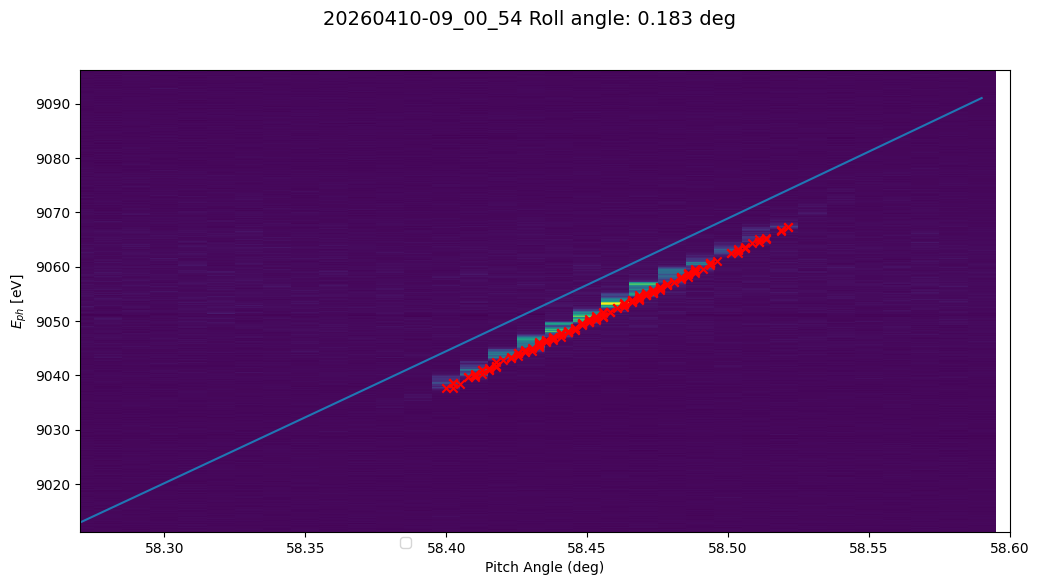

2 20260410-09_15_58_cor2d.npz
2 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
0.18268823181652655
Monochromator 2 image found; 
Machine status file found: roll angle=0.1827 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


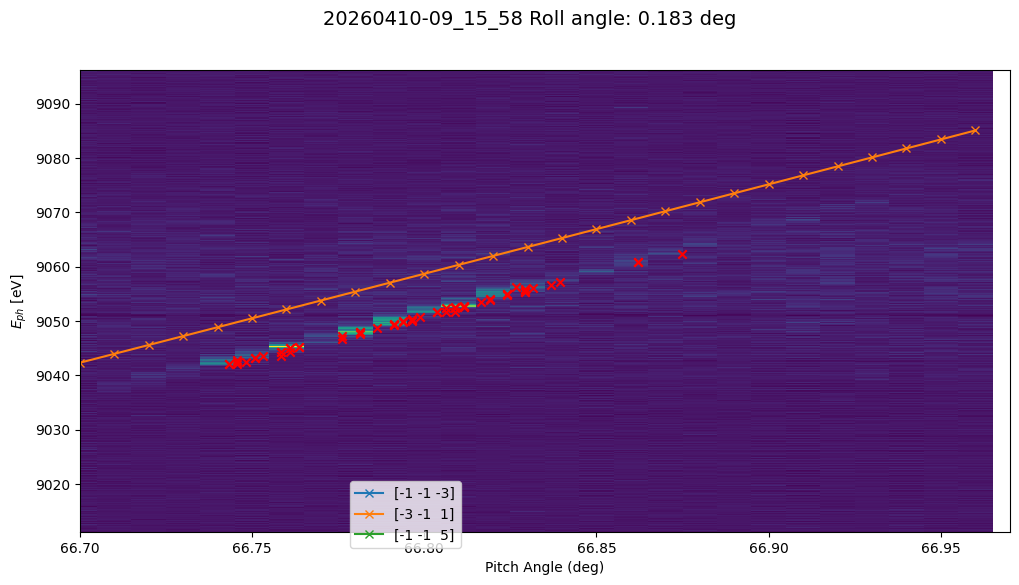

3 20260410-09_26_27_cor2d.npz
3 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
0.18268823181652655
Monochromator 2 image found; 
Machine status file found: roll angle=0.1827 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


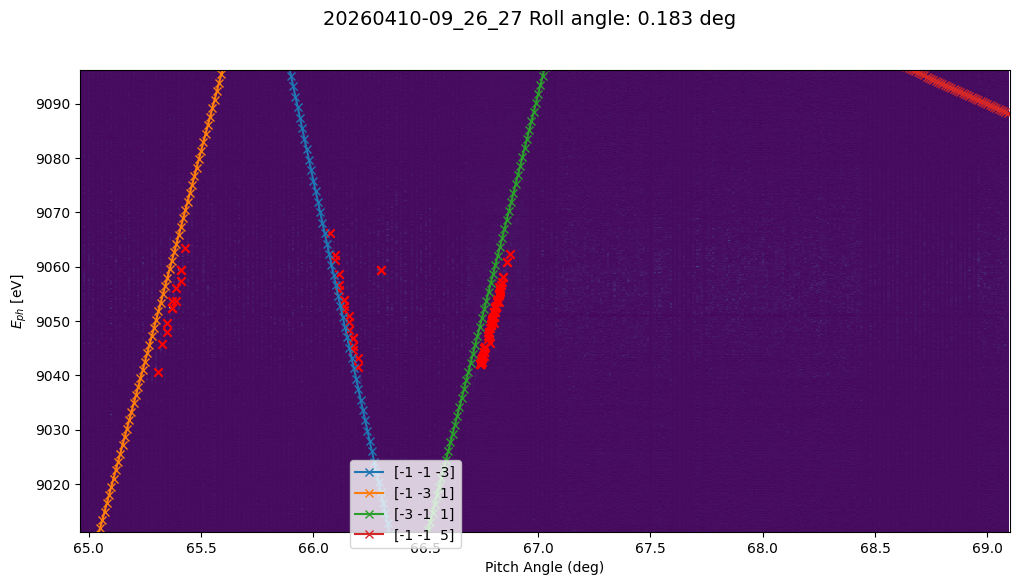

4 20260410-09_26_32_cor2d.npz
4 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
0.18268823181652655
Monochromator 2 image found; 
Machine status file found: roll angle=0.1827 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


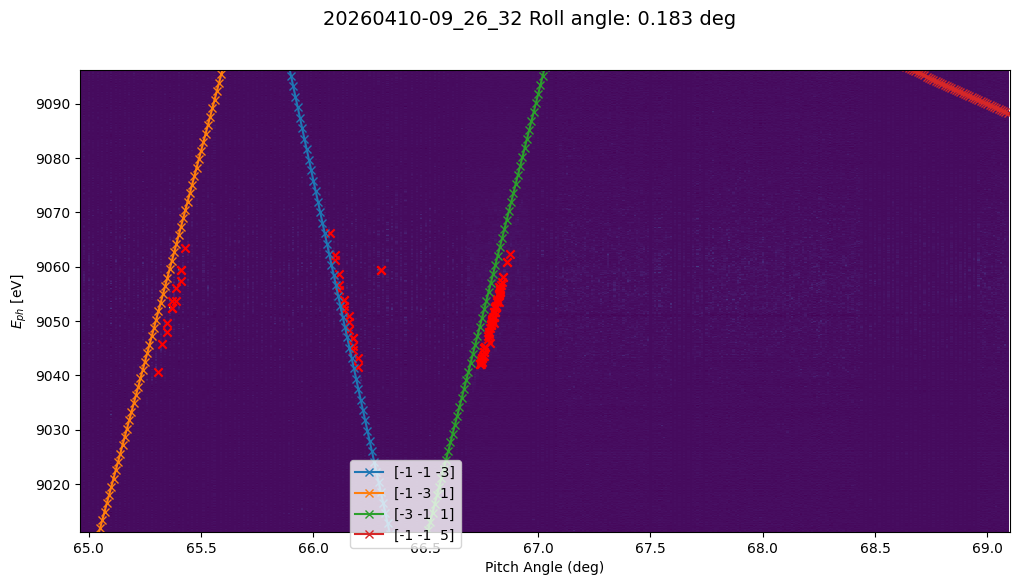

5 20260410-09_47_28_cor2d.npz
5 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
Error occurred: index 0 is out of bounds for axis 0 with size 0
Monochromator 2 image found; Default roll angle set (1 deg).
tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


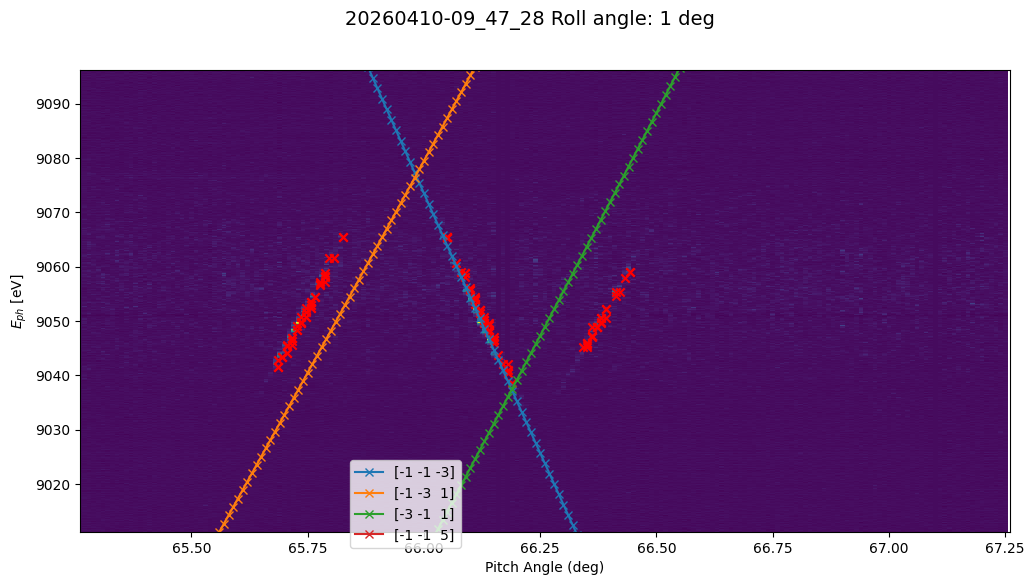

6 20260410-09_57_45_cor2d.npz
6 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
0.18268823181652655
Monochromator 2 image found; 
Machine status file found: roll angle=0.1827 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


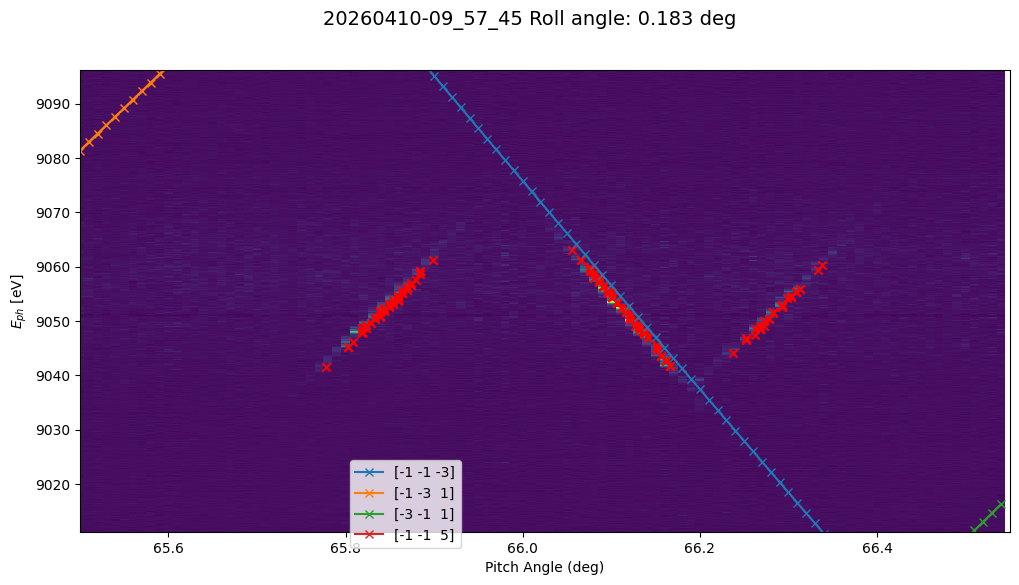

7 20260410-10_07_08_cor2d.npz
7 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.453888247233049
Monochromator 2 image found; 
Machine status file found: roll angle=1.4539 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


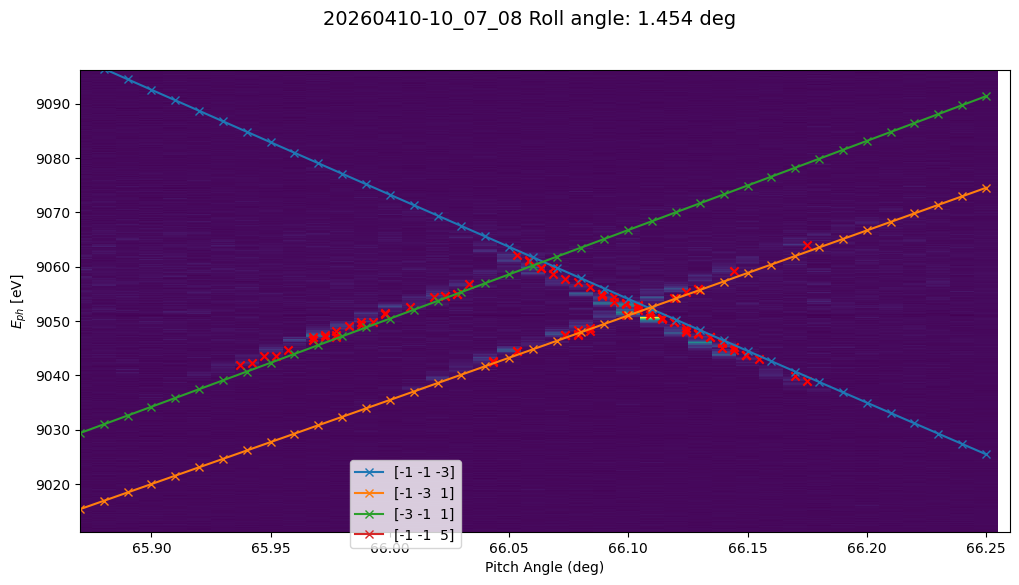

8 20260410-10_15_12_cor2d.npz
8 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.5065916108163606
Monochromator 2 image found; 
Machine status file found: roll angle=1.5066 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


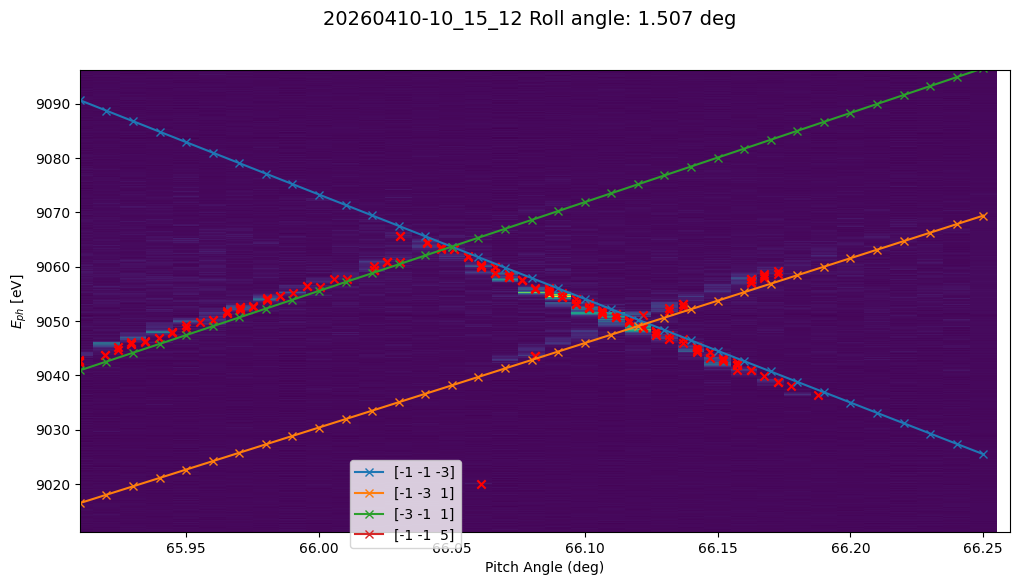

9 20260410-10_21_38_cor2d.npz
9 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.4802397724324925
Monochromator 2 image found; 
Machine status file found: roll angle=1.4802 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


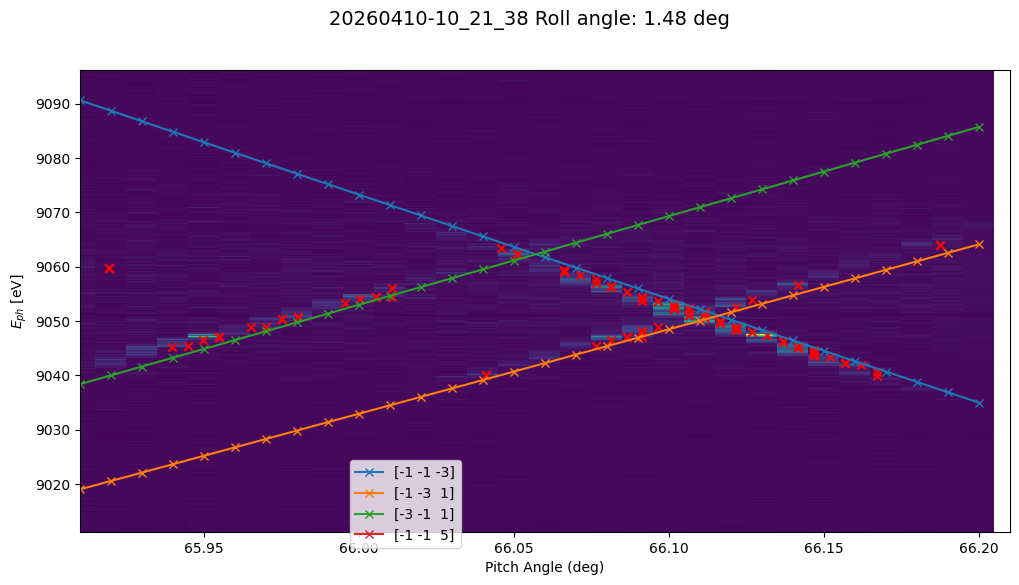

10 20260410-10_32_04_cor2d.npz
10 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.6120022079178824
Monochromator 2 image found; 
Machine status file found: roll angle=1.612 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


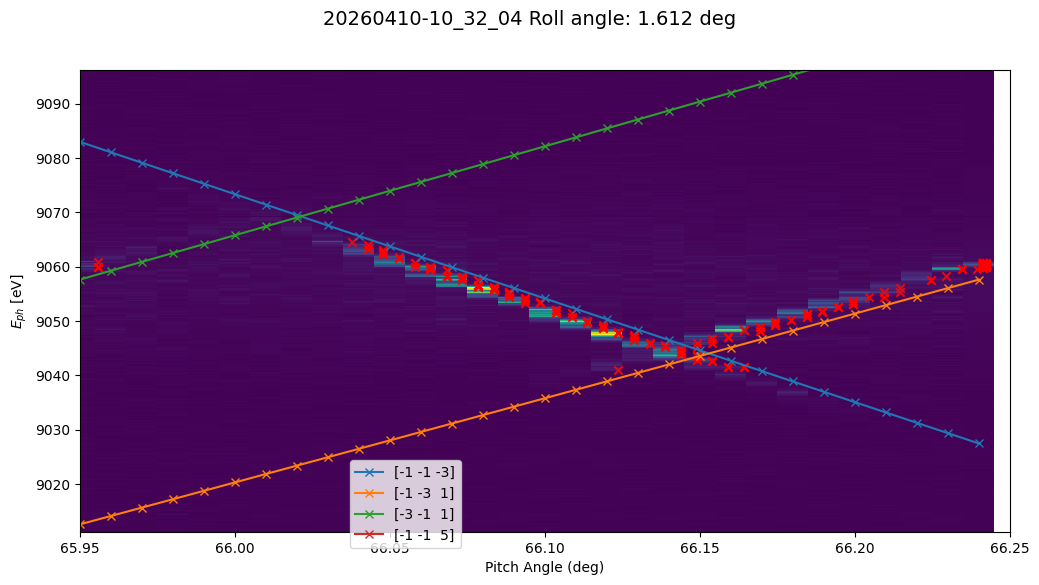

11 20260410-10_51_18_cor2d.npz
11 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONORA.2307.SA2/ACTUALPOSITION
11 20260410-10_52_03_cor2d.npz
11 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONORA.2307.SA2/ACTUALPOSITION
11 20260410-10_59_33_cor2d.npz
11 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


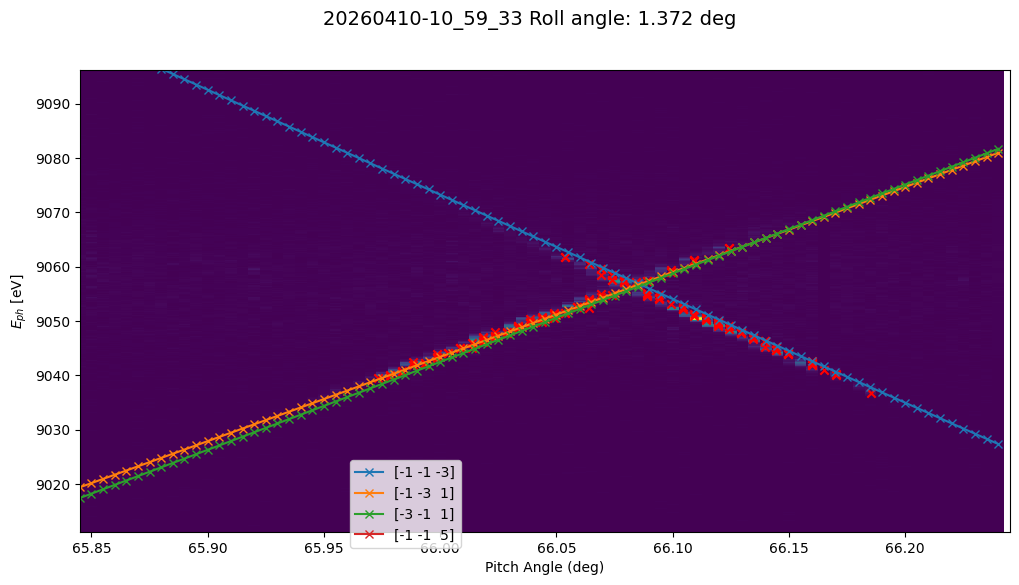

12 20260410-11_01_50_cor2d.npz
12 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


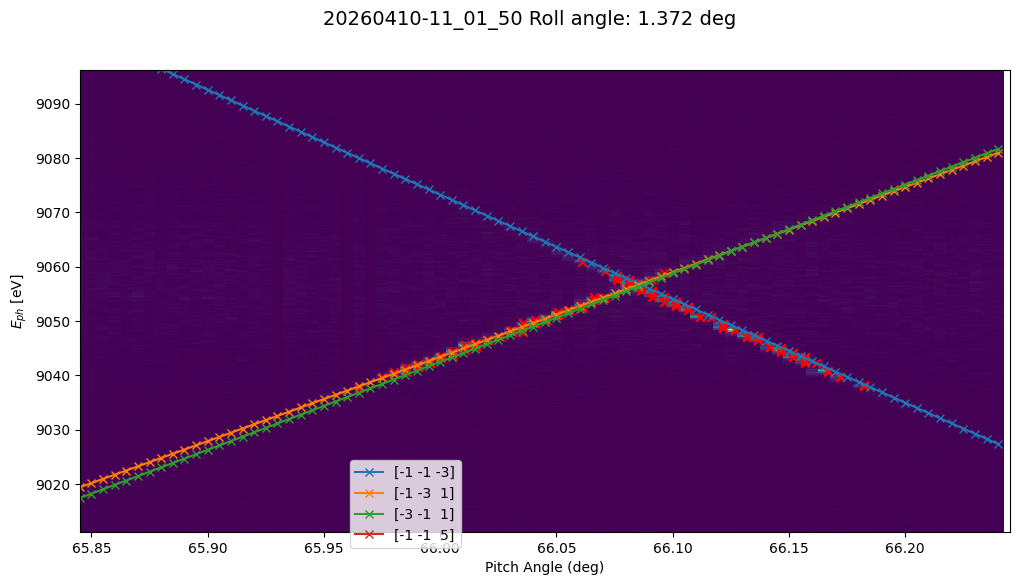

13 20260410-11_02_09_cor2d.npz
13 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


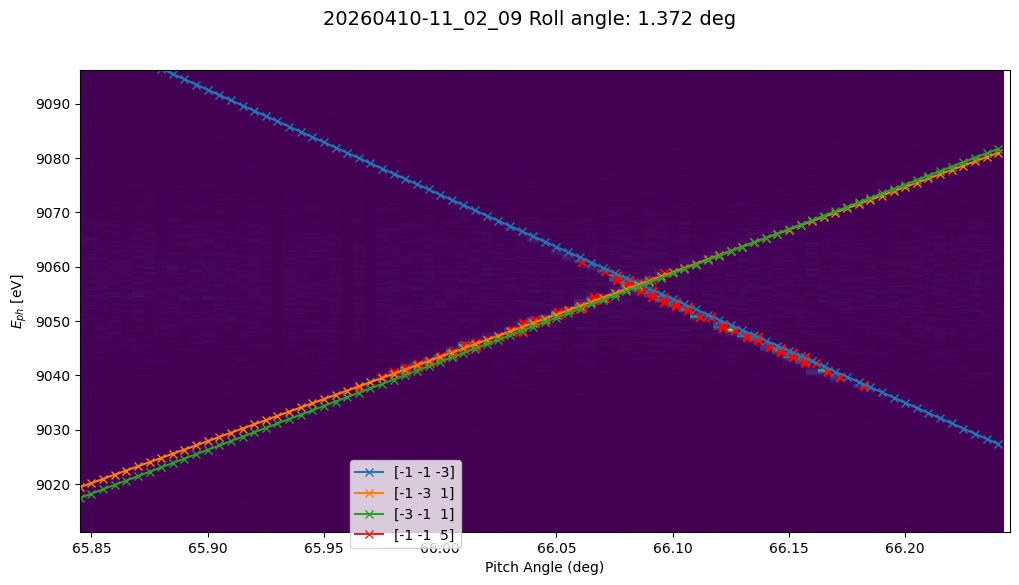

14 20260410-11_10_50_cor2d.npz
14 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


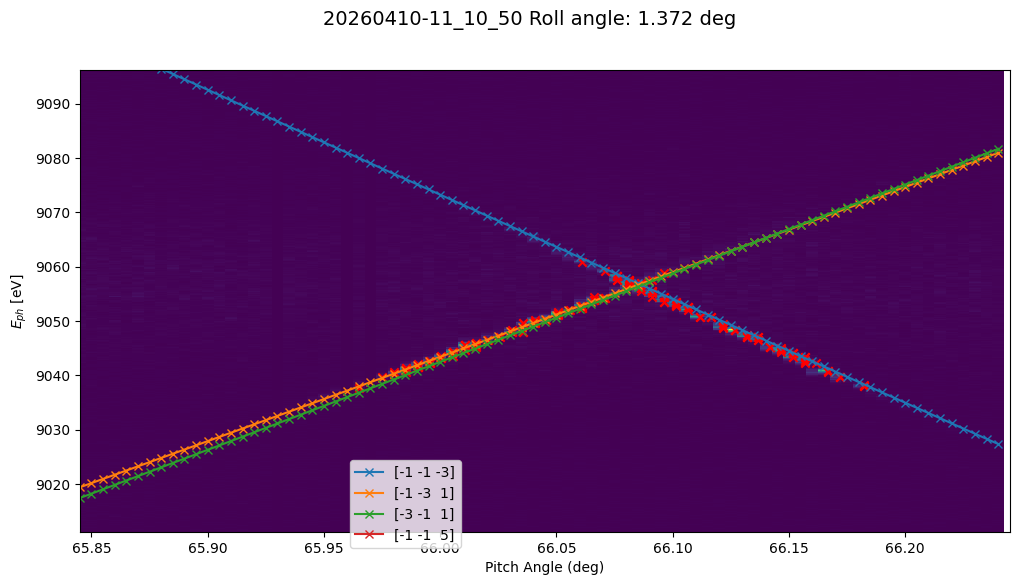

15 20260410-11_37_47_cor2d.npz
15 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


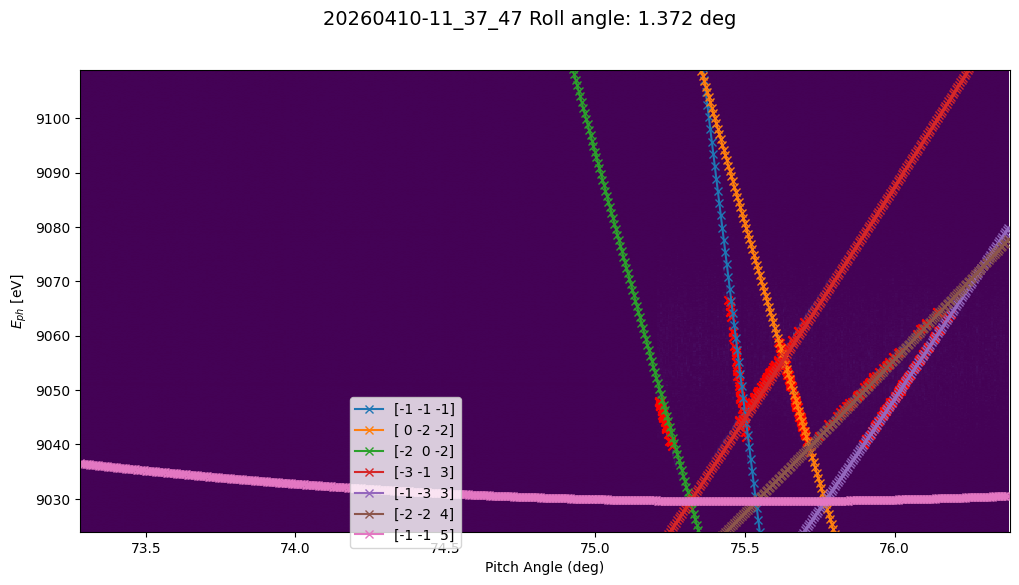

16 20260410-12_39_31_cor2d.npz
16 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


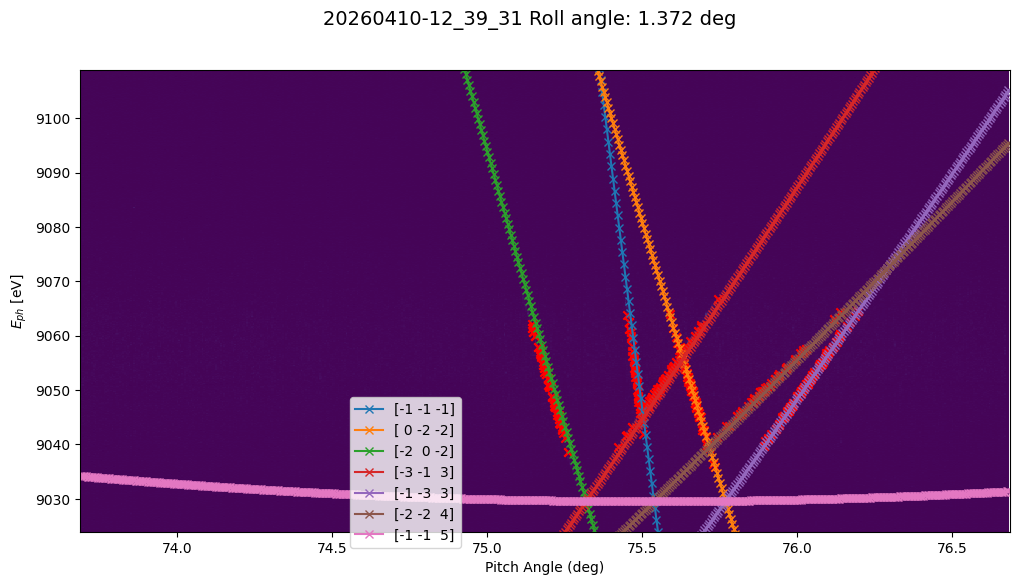

17 20260410-12_42_08_cor2d.npz
17 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


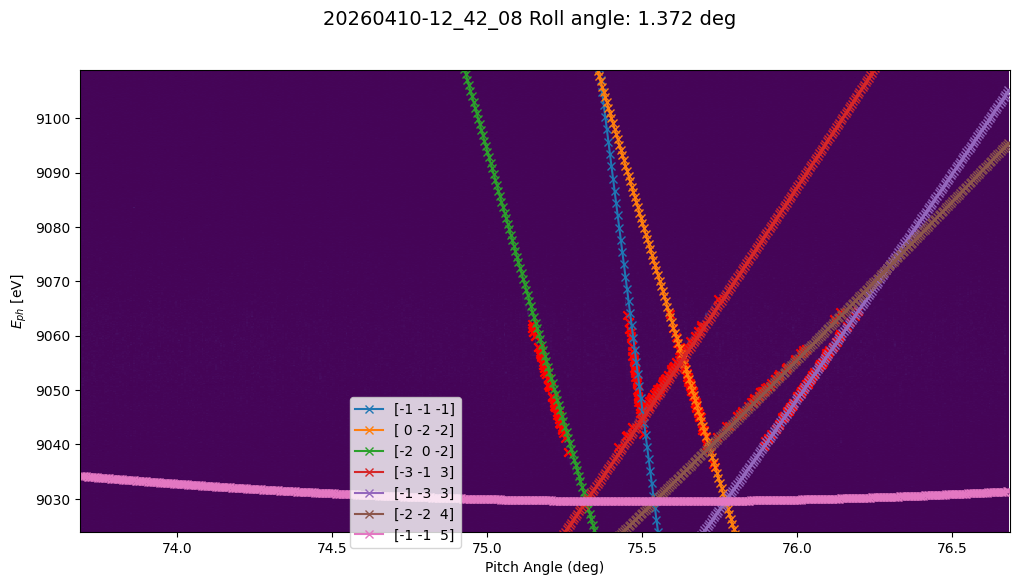

18 20260410-12_50_02_cor2d.npz
18 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


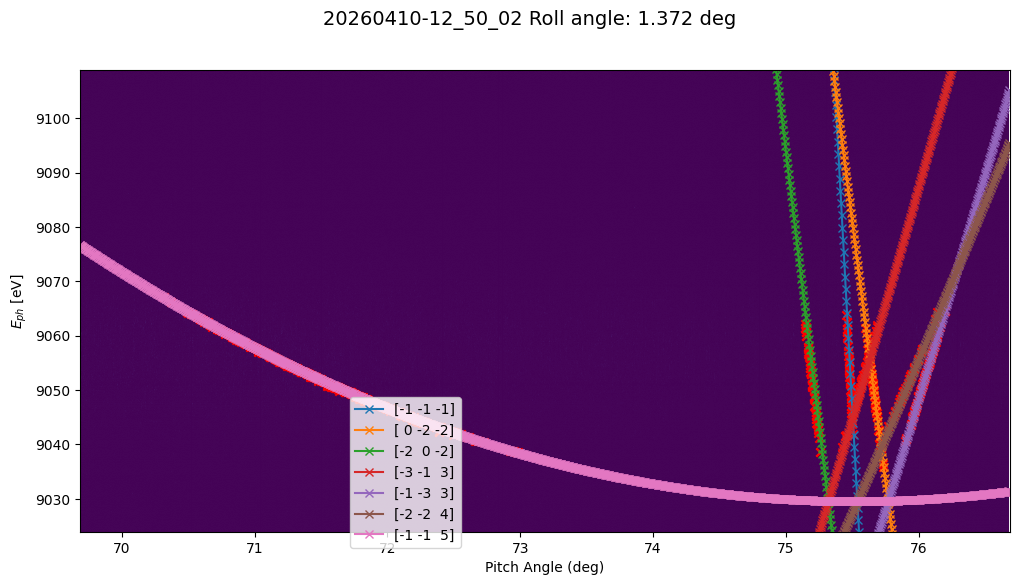

19 20260410-13_03_56_cor2d.npz
19 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


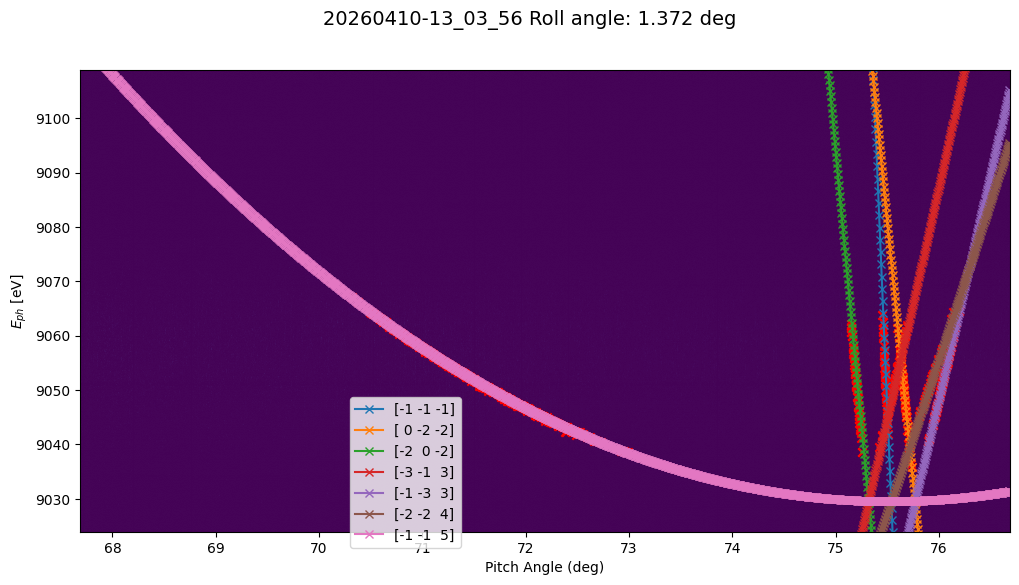

20 20260410-13_07_49_cor2d.npz
20 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


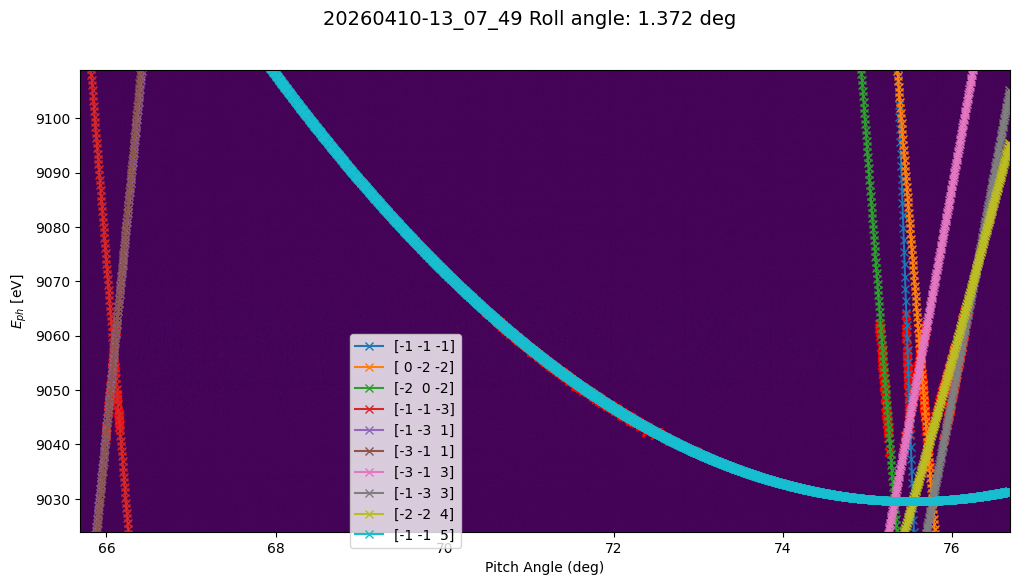

21 20260410-13_09_20_cor2d.npz
21 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


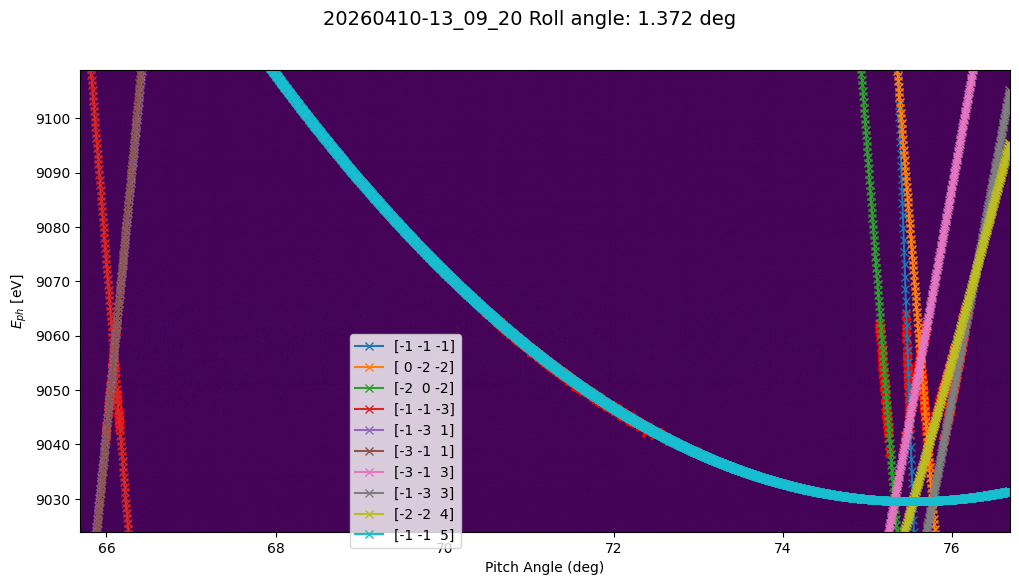

22 20260410-13_47_14_cor2d.npz
22 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


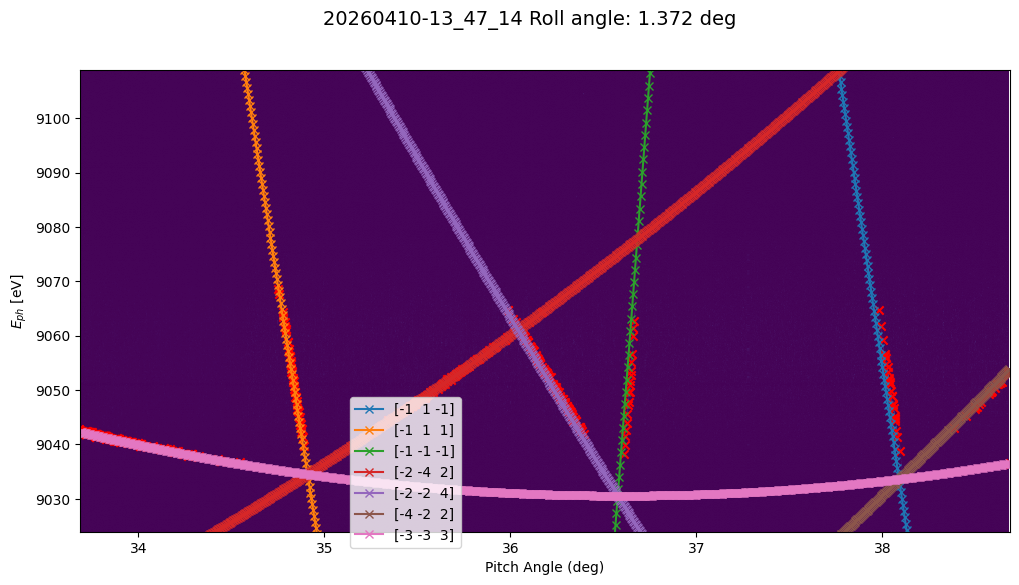

23 20260410-13_54_52_cor2d.npz
23 XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION
1.371541688064322
Monochromator 2 image found; 
Machine status file found: roll angle=1.3715 deg 

tuff


/tmp/ipykernel_957367/3170219976.py:112: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitches_Hd, EBragg, '-x', label=gid)


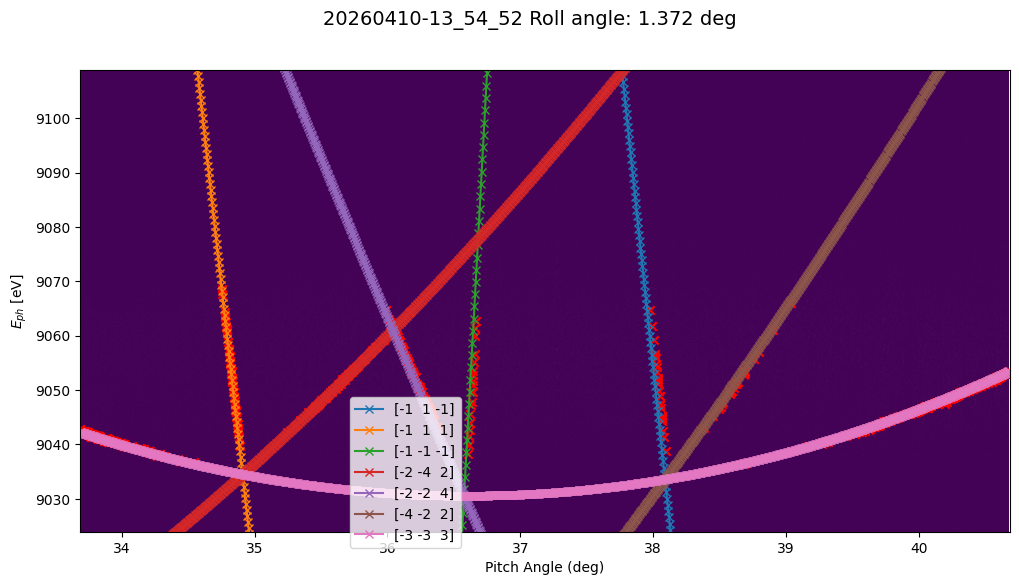

In [18]:
directory = r'/home/patrickt/DESYCLOUD/PostDoc/HXRSS/CalibrationData/apr2026/' 
pitch_tot = []
pitch_dict = {}
seeding_energy_tot = []
seeding_energy_dict = {}
roll_tot = []
roll_dict = {}
Hquery_dict = {}
Hqueryd_dict = {}

m=0
datafiles = []
thresfact = 1/10
do_analysis = True
plot_marks = True
wEcorr = True
for file in sorted(os.listdir(directory)):  
    # if m>1:
        # break
    filename = os.fsdecode(file)
    if filename.endswith('cor2d.npz'):# and (filename.find("20240831")>=0 or filename.find("20240901")>=0):
        xfromnpphen = False
        filepath=os.path.join(directory, file)
        #datafiles.append(filepath)
        tt = np.load(filepath, allow_pickle=True)
        corr2d = tt['corr2d']
        orig_image = tt['corr2d'].T
        spec_hist = tt['spec_hist']
        

        doocs_scale = tt['doocs_scale']
        np_phen = tt['phen_scale']#+en
        doocs_vals_hist = tt['doocs_vals_hist']
        doocs_label = tt['doocs_channel']
        date_raw=filename[ 0 : 17 ]
        date_time_obj = datetime.strptime(date_raw, '%Y%m%d-%H_%M_%S')
        if date_time_obj < datetime(2026,4,10,11,17,0):
            phen_scale_hist = (np.arange(0,spec_hist.shape[1])-1550)*0.18 + 9080 #from screenshot...
            E_central = 9080
            E_corr = -15
        else:
            phen_scale_hist = (np.arange(0,spec_hist.shape[1])-1550)*0.18 + 9065 #from screenshot...
            E_central = 9065
            E_corr = 0
            
        # check if the image corresponds to a crystal pitch angle scan. MONOPA 
        print(m+1,filename)
        print(m+1,doocs_label)
        if "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONOPA.2307.SA2/ACTUALPOSITION" in doocs_label or "XFEL.FEL/UNDULATOR.SASE2/MONOPA.2307.SA2/ANGLE" in doocs_label:
            datafiles.append(filepath)
            date_raw=filename[ 0 : 17 ]
            date_time_obj = datetime.strptime(date_raw, '%Y%m%d-%H_%M_%S') #strip date from image filename
            m=m+1
            
            if do_analysis:
                # Search for corresponding roll angle from the status file or the database pickle file.
                roll_angle = roll_in_database(filepath)
                

                xfromnpphen = True
                doocs_scale += 259.77
                if len(doocs_scale) != len(orig_image):
                    np_doocs=doocs_scale[:-1]
                else:
                    np_doocs=doocs_scale
                
                
                # if np_phen.min()>9100:
                #     np_phen -= 220.205399303666535
                # pcentral = np.argmin(np.abs(tt['phen_scale']-Ecentral))

                #_loc =  [(E_H-Ecentral_orig)*disp_HIREX/dEdP_orig + Ecentral_orig-Ecorr
                # x = dEdP*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral
                if wEcorr:
                    #np_phen = (tt['phen_scale']-Ecentral)*dEdP/disp_orig + Ecentral + E_corr
                    #np_phen_hist_corr = x = (phen_scale_hist - Ecentral)*dEdP/disp_orig + Ecentral + E_corr
                    np_phen = pivot + disp_fact * (tt['phen_scale'] + E_corr - pivot)
                    np_phen_hist_corr = x = pivot + disp_fact * (phen_scale_hist  + E_corr- pivot)
                else:
                    x = phen_scale_hist
                # np_phen += en
                # Original image plot
                fig, ax = plt.subplots(1, 1, figsize=(12, 6))
                fig.suptitle(date_raw+' Roll angle: '+str(np.round(roll_angle,3))+' deg', fontsize=14)
                
                plot = ax.pcolormesh(np_doocs, np_phen, orig_image, cmap='viridis', shading='auto')
                # phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll_angle)
                
                # for phen, pangle, gid in zip(phen_list, p_angle_list, gid_list):
                #     ph_axis, pa_axis = [], []
                #     for ph_value, pa_value in zip(phen, pangle):
                #         # Only keep photon energies within a close range of the spectrometer image range
                #         if ph_value > np_phen[0]-170 and ph_value < np_phen[-1]+170 and pa_value >= min(doocs_scale)-1.2 and pa_value <= max(doocs_scale)+1.2:
                #             ph_axis.append(ph_value)
                #             pa_axis.append(pa_value)
                #     if ph_axis == []:
                #         pass
                #     else:
                #         plt.plot(pa_axis, ph_axis, '--', label=gid, linewidth=3)
                #         pass

                Eph_Hd, pitches_Hd, Hqueryd = getlocal_Hplanes_ddiff(hmax, kmax, lmax, dP, dR, dY, dRP,dYP,roll_angle,np_phen,np_doocs)
                # Hquery_dict[str(m)] = Hquery
                Hqueryd_dict[str(m)] = Hqueryd

                # for Hidx, (ph_axis,pa_axis,gid) in enumerate(zip(Eph_H,pitches_H,Hquery)):
                #     EBragg = [ph + Ecorr for ph in ph_axis]
                #     plt.plot(pa_axis, EBragg, '-.', label=gid)
                if Hqueryd.shape[0]>1:
                    for Hidx, (ph_axis,gid) in enumerate(zip(Eph_Hd.T,Hqueryd.T)):
                        EBragg = [ph + Ecorr for ph in ph_axis]
                        plt.plot(pitches_Hd, EBragg, '-x', label=gid)
                else:
                    plt.plot(pitches_Hd, Eph_Hd)
                ax.set_xlabel('Pitch Angle (deg)')
                ax.set_ylabel(r'$E_{ph}$ [eV]')
                ax.set_ylim(np_phen[0], np_phen[-1])
                ax.set_xlim(doocs_scale[0], doocs_scale[-1])
                ax.legend(loc=8, bbox_to_anchor=(0.35,-0.05))


                #extract pitch, roll and energy
                


                filter_arr = []
                seeding_energy = []
                thres = spec_hist.max()*thresfact


                # en = 72
                #x = np_phen
                # if xfromnpphen:
                #     x = np_phen.copy()
                    
                # else:
                #     E0=9010
                #     px1=1000
                #     ev_px = 0.35
                    
                #     start = E0 - px1*ev_px
                #     stop = E0 + (1280 - px1) * ev_px
                #     x = np.linspace(start, stop, num=1280)
                for spectrum in spec_hist:

                    if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
                        filter_arr.append(True)
                        seeding_energy.append(x[np.argmax(spectrum)])
                    else:
                        filter_arr.append(False)
                
                #seems to be somewhat incorrect --> use different
                # for idx,spectrum in enumerate(corr2d):
                #     x = np_phen
                #     if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
                #         filter_arr.append(True)
                #         seeding_energy.append(x[np.argmax(spectrum)])
                #     else:
                #         filter_arr.append(False)

                pitch = tt['doocs_vals_hist'][filter_arr] + 259.77
            # pitch = np_doocs[filter_arr]
                roll = np.ones(pitch.size)*roll_angle
                pitch_tot += pitch.tolist()
                roll_tot += roll.tolist()
                seeding_energy_tot += seeding_energy
                pitch_dict[str(m)] = pitch
                roll_dict[str(m)] = roll_angle
                seeding_energy_dict[str(m)] = seeding_energy
                if plot_marks:
                    ax.scatter(pitch,seeding_energy,color='r',marker='x')

                plt.show()
        elif "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONORA.2252.SA2/ACTUALPOSITION" in doocs_label or "XFEL.FEL/UNDULATOR.SASE2/MONORA.2307.SA2/ANGLE" in doocs_label:
            datafiles.append(filepath)
            date_raw=filename[ 0 : 17 ]
            date_time_obj = datetime.strptime(date_raw, '%Y%m%d-%H_%M_%S') #strip date from image filename
            m=m+1
            print(m)
            if do_analysis:
                # Search for corresponding roll angle from the status file or the database pickle file.
                if "XFEL.FEL/UNDULATOR.SASE2/MONORA.2252.SA2/ANGLE" in doocs_label:#
                    mono_no_pitch = 1
                    try:
                        filedata = np.loadtxt(
                            filepath+'_status.txt', dtype='str', delimiter=',', skiprows=1)
                        pa_pos = np.where(
                            filedata == 'XFEL.FEL/UNDULATOR.SASE2/MONOPA.2252.SA2/ANGLE')
                        pa_row = pa_pos[0][0]
                        pitch_angle = float(filedata[pa_row][1])
                        print('Monochromator 1 image found; \nMachine status file found: pitch angle=' + str(np.round(pitch_angle, 4)) + ' deg \n')
                    except:
                        try:
                            berlin = pytz.timezone('Europe/Berlin')
                            df_db['date_full'] = pd.to_datetime(df_db['date_full'], utc=True)
                            df_db['date_full'] = df_db['date_full'].dt.tz_convert("Europe/Paris")
                            dt = date_time_obj
                            dt = dt.replace(tzinfo=berlin)
                            pitch = df_db['pitch_angle'].loc[(df_db['date_full'] == nearest(df_db['date_full'], dt)) ]
                            pitch_angle = float(pitch.iloc[0])
                            print('Monochromator 1 image found; from database: pitch angle=' + str(np.round(pitch_angle, 4)) + ' deg \n')
                        except:
                            pitch_angle = 90
                            print('Monochromator 1 image found; Default pitch angle set (90 deg).')
                elif "XFEL.FEL/HXRSS_MONO2_MOTOR.SA2/MONORA.2307.SA2/ACTUALPOSITION" in doocs_label:
                    mono_no_pitch = 2
                    try:
                        filedata = np.loadtxt(
                            filepath+'_status.txt', dtype='str', delimiter=',', skiprows=1)
                        pa_pos = np.where(
                            filedata == 'XFEL.FEL/UNDULATOR.SASE2/MONOPA.2307.SA2/ANGLE')
                        pa_row = pa_pos[0][0]
                        pitch_angle = float(filedata[pa_row][1]) + 259.77
                        print('Monochromator 2 image found; \nMachine status file found: pitch angle=' + str(np.round(pitch_angle, 4)) + ' deg \n')
                    except:
                        try:
                            berlin = pytz.timezone('Europe/Berlin')
                            df_db['date_full'] = pd.to_datetime(df_db['date_full'], utc=True)
                            df_db['date_full'] = df_db['date_full'].dt.tz_convert("Europe/Paris")
                            dt = date_time_obj
                            dt = dt.replace(tzinfo=berlin)
                            pitch = df_db['pitch_angle'].loc[(df_db['date_full'] == nearest(df_db['date_full'], dt)) ]
                            pitch_angle = float(pitch.iloc[0])
                            print('Monochromator 2 image found; from database: pitch angle=' + str(np.round(pitch_angle, 4)) + ' deg \n')
                        except:
                            pitch_angle = 1
                            print('Monochromator 2 image found; Default pitch angle set (1 deg).')
                else: 
                    mono_no_roll = 0
                    print('No pitch angle')
                
                doocs_scale = np.rad2deg(np.arcsin((doocs_scale+2.2774)/87)) 
                if len(doocs_scale) != len(orig_image):
                    np_doocs=doocs_scale[:-1]
                else:
                    np_doocs=doocs_scale
                
                # pcentral = np.argmin(np.abs(tt['phen_scale']-Ecentral_orig))
            
                # x = dEdP*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral
                # np_phen = x
                if wEcorr:
                    #np_phen = (tt['phen_scale']-Ecentral)*dEdP/disp_orig + Ecentral + E_corr
                    #np_phen_hist_corr = x = (phen_scale_hist - Ecentral)*dEdP/disp_orig + Ecentral + E_corr
                    np_phen = pivot + disp_fact * (tt['phen_scale'] + E_corr - pivot)
                    np_phen_hist_corr = x = pivot + disp_fact * (phen_scale_hist  + E_corr- pivot)
                else:
                    x = phen_scale_hist
                # if np_phen.min()>9100:
                #     np_phen -= 220.205399303666535
                #     xfromnpphen = True
                    
                # Original image plot
                fig, ax = plt.subplots(1, 1, figsize=(12, 6))
                fig.suptitle(date_raw+' pitch angle: '+str(np.round(pitch_angle,3))+' deg', fontsize=14)
                
                plot = ax.pcolormesh(np_doocs, np_phen, orig_image, cmap='viridis', shading='auto')
                # phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll_angle)
                
                # for phen, pangle, gid in zip(phen_list, p_angle_list, gid_list):
                #     ph_axis, pa_axis = [], []
                #     for ph_value, pa_value in zip(phen, pangle):
                #         # Only keep photon energies within a close range of the spectrometer image range
                #         if ph_value > np_phen[0]-170 and ph_value < np_phen[-1]+170 and pa_value >= min(doocs_scale)-1.2 and pa_value <= max(doocs_scale)+1.2:
                #             ph_axis.append(ph_value)
                #             pa_axis.append(pa_value)
                #     if ph_axis == []:
                #         pass
                #     else:
                #         plt.plot(pa_axis, ph_axis, '--', label=gid, linewidth=3)
                #         pass
                #Eph_H, rolls_H, Hquery = getlocal_Hplanes_roll(hmax, kmax, lmax, dthp, dthy, dthr, alpha, pitch_angle,np_phen,np_doocs)
                Eph_Hd, rolls_Hd, Hqueryd = getlocal_Hplanes_roll_ddiff(hmax, kmax, lmax,  dP, dR, dY,  dRP, dYP, pitch_angle,np_phen,np_doocs)
                Hqueryd_dict[str(m)] = Hqueryd
    
                for Hidx, (ph_axis,gid) in enumerate(zip(Eph_Hd.T,Hqueryd.T)):
                    EBragg = [ph for ph in ph_axis]
                    plt.plot(rolls_Hd, EBragg, '-x', label=gid)
                ax.set_xlabel('Roll Angle (deg)')
                ax.set_ylabel(r'$E_{ph}$ [eV]')
                ax.set_ylim(np_phen[0], np_phen[-1])
                ax.set_xlim(doocs_scale[0], doocs_scale[-1])
                ax.legend(loc=8, bbox_to_anchor=(0.35,-0.05))


                #extract pitch, roll and energy
                


                filter_arr = []
                seeding_energy = []
                thres = spec_hist.max()*thresfact


                
                # en = 72
                #x = np_phen
                # if xfromnpphen:
                #     x = np_phen.copy()
                #     # for spectrum in spec_hist:
                #     #     if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
                #     #         filter_arr.append(True)
                #     #         seeding_energy.append(x[np.argmax(spectrum)]+en)
                #     #     else:
                #     #         filter_arr.append(False)
                #     # pitch = np_doocs[filter_arr]
                    
                # else:
                #     E0=9010
                #     px1=1000
                #     ev_px = 0.35
                    
                #     start = E0 - px1*ev_px
                #     stop = E0 + (1280 - px1) * ev_px
                #     x = np.linspace(start, stop, num=1280)
                for spectrum in spec_hist:

                    if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
                        filter_arr.append(True)
                        seeding_energy.append(x[np.argmax(spectrum)])
                    else:
                        filter_arr.append(False)
                
                #seems to be somewhat incorrect --> use different
                # for idx,spectrum in enumerate(corr2d):
                #     x = np_phen
                #     if np.max(spectrum) > thres: ## Adjust this number to adjust threshold 
                #         filter_arr.append(True)
                #         seeding_energy.append(x[np.argmax(spectrum)])
                #     else:
                #         filter_arr.append(False)

                roll = tt['doocs_vals_hist'][filter_arr]
            # pitch = np_doocs[filter_arr]
                pitch = np.ones(roll.size)*roll_angle
                pitch_tot += pitch.tolist()
                roll_tot += roll.tolist()
                seeding_energy_tot += seeding_energy
                pitch_dict[str(m)] = pitch_angle
                roll_dict[str(m)] = roll
                seeding_energy_dict[str(m)] = seeding_energy
                if plot_marks:
                    ax.scatter(roll,seeding_energy,color='r',marker='x')

                plt.show()
                
                #if m ==13:
                #    break
                



True

(0.0, 1.0)

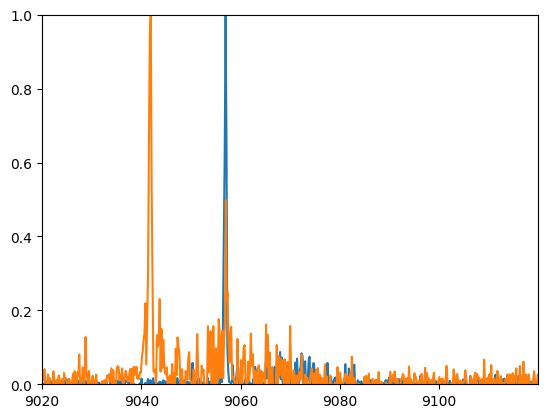

In [34]:
phen_hist_scale = (np.arange(0,spec_hist.shape[1])-1550)*0.18 + 9080
plt.plot(phen_hist_scale,spec_hist[0, :]/spec_hist[0,:].max())
plt.plot(np_phen,corr2d[0, :]/corr2d[0, :].max())
plt.xlim(np_phen.min(),np_phen.max())
plt.ylim(0,1)


In [30]:
np_phen

array([9019.91137163, 9020.09144197, 9020.27151231, 9020.45158265,
       9020.63165299, 9020.81172333, 9020.99179367, 9021.17186401,
       9021.35193435, 9021.53200469, 9021.71207503, 9021.89214537,
       9022.07221571, 9022.25228605, 9022.43235639, 9022.61242673,
       9022.79249707, 9022.97256741, 9023.15263775, 9023.33270809,
       9023.51277843, 9023.69284877, 9023.87291911, 9024.05298945,
       9024.23305979, 9024.41313013, 9024.59320047, 9024.77327081,
       9024.95334115, 9025.13341149, 9025.31348183, 9025.49355217,
       9025.67362251, 9025.85369285, 9026.03376319, 9026.21383353,
       9026.39390387, 9026.57397421, 9026.75404455, 9026.93411489,
       9027.11418523, 9027.29425557, 9027.47432591, 9027.65439625,
       9027.83446659, 9028.01453693, 9028.19460727, 9028.37467761,
       9028.55474795, 9028.73481829, 9028.91488863, 9029.09495897,
       9029.27502931, 9029.45509965, 9029.63516999, 9029.81524033,
       9029.99531067, 9030.17538101, 9030.35545135, 9030.53552

# multiple sets of lines together (scans number 2)

In [9]:
# #start with current fix=3
pitch_acc = []
E_H_acc = []
roll_acc = []#roll for idx in range(len(pitch_acc))]
Hquery_acc = []#Hquery
HtoMeas_acc = []
Hqueryd_acc = []#Hquery
HtoMeasd_acc = []
dEdP_orig = 0.15
Ecentral_orig = 12407
# dPguess,dRguess,dYguess,dRPguess,Ecorrguess = [ 1.14473852e+00,  1.10991002e+00, -1.01729259e+00,  1.07575895e-02, -5.83095293e+00]
#dPguess,dRguess,dYguess,dRPguess,Ecorrguess = [1.15497246, 0.61820617, -0.82300946,  0.01643269, -7.39200109]
dPguess,dRguess,dYguess,dRPguess,Ecorrguess = [1.15032315,  1.28583585, -1.23740417,  0.00881059, -6.36851326]
# dPguess,dRguess,dYguess,dRPguess,Ecorrguess = [ 1.14473852e+00,  1.10991002e+00, -1.01729259e+00,  1.07575895e-02, 1]
#[ 1.07751213e+00,  2.10995426e+00 ,-2.26427577e+00, -2.55980253e-03, -1.50456395e+01]

### scan #2

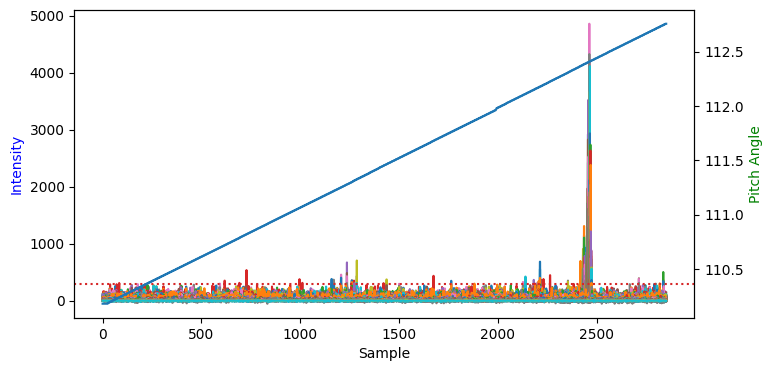

['[1, -3, -1]', '[1, 1, -1]', '[1, 1, 7]', '[2, 4, 2]', '[3, 3, 5]', '[4, 2, 2]']


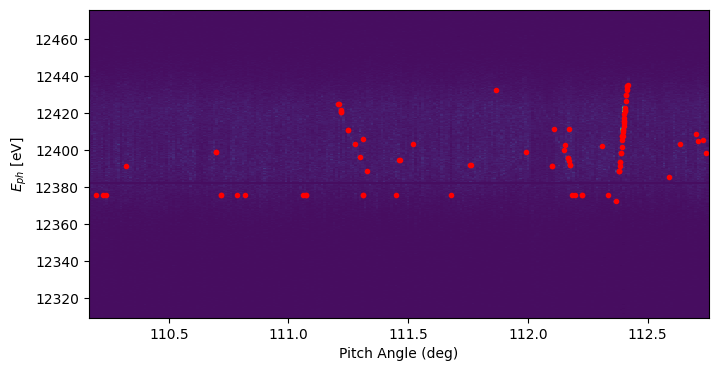

In [10]:
fidx = 2
tt = np.load(datafiles[fidx-1], allow_pickle=True)


fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()


thresh = tt['spec_hist'].max()/17

doocs_scale = tt['doocs_scale']
if len(doocs_scale) != len(orig_image):
    np_doocs=doocs_scale[:-1]
else:
    np_doocs=doocs_scale
#thresh = tt['spec_hist'].max()/6
ax1.plot(tt['spec_hist'])
ax1.axhline(thresh,ls=":",color='tab:red')
ax2.plot(tt['doocs_vals_hist'])

ax1.set_xlabel('Sample')
ax2.set_ylabel('Pitch Angle', color='g')
ax1.set_ylabel('Intensity', color='b')
#plt.xlim(16300, 16700)
plt.show()
filter_arr = []
seeding_energy = []
en = 0

x = tt['phen_scale']

pcentral = np.argmin(np.abs(x-Ecentral_orig))

x = dEdP_orig*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral_orig
np_phen = x
for spectrum in tt['spec_hist']:

    if np.max(spectrum) > thresh: ## Adjust this number to adjust threshold 
        filter_arr.append(True)
        seeding_energy.append(x[np.argmax(spectrum)]+en)
    else:
        filter_arr.append(False)


pitch = tt['doocs_vals_hist'][filter_arr]
seeding_energy_dict[str(fidx)] = seeding_energy
pitch_dict[str(fidx)] = pitch
pitches = pitch
Eph_seed = np.array(seeding_energy_dict[str(fidx)])#np.array(seeding_energy_dict
try:
    roll = roll_dict[str(fidx)]
    Hquery = Hquery_dict[str(fidx)]
    Hqueryd = Hqueryd_dict[str(fidx)]
except:
    roll = roll_in_database(datafiles[fidx-1])
    _, _, Hqueryd = getlocal_Hplanes_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
    _, _, Hquery = getlocal_Hplanes(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
print(Hquery)
# Plot extracted lines
# seeding_energy = seeding_energy_dict[str(fidx)]
# pitch = pitch_dict[str(fidx)]
fig, ax = plt.subplots(figsize=(8,4))

plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')
plt.plot(pitch, seeding_energy, 'r.')
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.show()


0 : [13, 14, 15, 16, 17, 18, 19, 20, 21, 25]
1 : [44, 45, 43, 40, 41, 38, 37]
2 : [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]


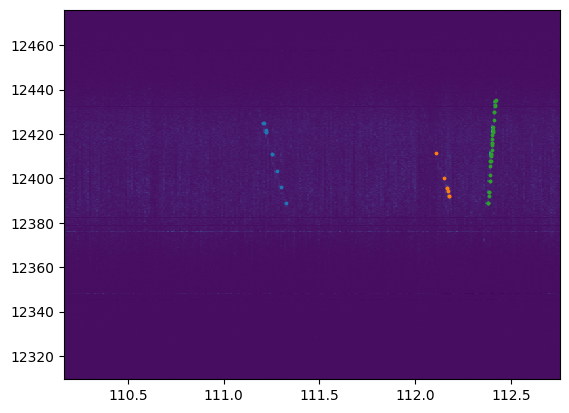

In [11]:
group_colors = ['red', 'green', 'blue', 'yellow','purple','magenta','orange']  # Different colors for different groups
group_labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7']
selected_points_by_group = {label: [] for label in group_labels}

selected_points_by_group['Group 1'] = [13, 14, 15, 16, 17, 18, 19, 20, 21, 25]
selected_points_by_group['Group 2'] = [44, 45, 43, 40, 41, 38, 37]
selected_points_by_group['Group 3'] = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]


pitches_H = []
E_H = []
plt.figure()
plt.pcolormesh(np_doocs,tt['phen_scale'] ,tt['corr2d'].T,shading='auto')

for lidx, points in enumerate(selected_points_by_group.values()):
    if(len(points)>0):
        pitches_H.append(pitches[points].squeeze())
        E_H.append(Eph_seed[points].squeeze())
        print(lidx,':',points)
        # print(lidx,':',pitches_H[lidx],'\n',E_H[lidx])
        plt.scatter(pitches_H[lidx],E_H[lidx],s=3)
plt.show()

In [ ]:
# Automated manual-selection sanity check
# This compares image-only peak/ridge candidates with the hand-selected groups above.
automation_result = run_automation_sanity_check(
    tt=tt,
    fidx=fidx,
    selected_points_by_group=selected_points_by_group,
    pitches=pitches,
    Eph_seed=Eph_seed,
    roll=roll,
    HtoMeas=HtoMeas,
    Hquery=Hquery,
    HtoMeasd=HtoMeasd,
    Hqueryd=Hqueryd,
    energy_axis=np_phen,
    angle_axis=tt["doocs_vals_hist"],
    np_doocs=np_doocs,
    energy_tolerance=10.0,
    plot=True,
)


In [11]:
Hquery,Hqueryd

(['[1, -3, -1]',
  '[1, 1, -1]',
  '[1, 1, 7]',
  '[2, 4, 2]',
  '[3, 3, 5]',
  '[4, 2, 2]'],
 array([array([-1, -1,  1]), array([-2, -4, -2]), array([-4, -2, -2]),
        array([-3, -3, -5]), array([-1, -1, -7])], dtype=object))

/tmp/ipykernel_21158/842142149.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]


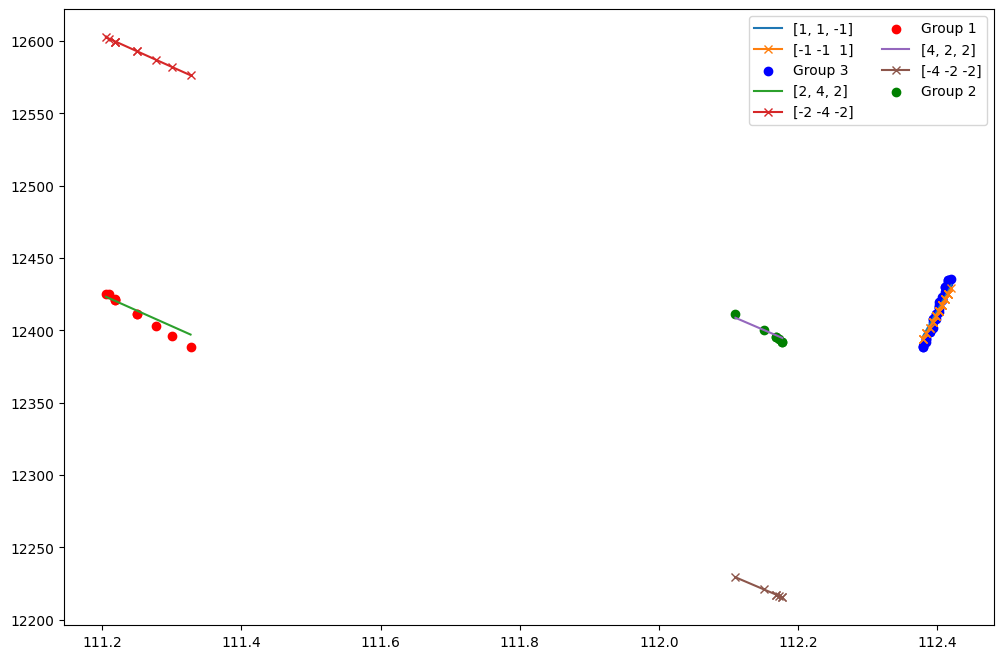

In [12]:
HtoMeas = [None,2,None,0,None,1]
HtoMeasd = np.array([2,0,1,None,None])
#HtoMeas = [2,0,1,0,0]
fig, ax = plt.subplots(figsize=(12,8))
#ax.scatter(pitches,seeding_energy,color='red')
for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    Hd = Hqueryd[HtoMeasd==lidx][0]
    if lidx is not None:
        pitchi = pitches_H[lidx]
        E_Hi = E_H[lidx]


        EBragg, linestyle = HXRSS_singleLine(json.loads(H),pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBraggd = HXRSS_singleLine_ddiff(Hd,pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        #EBragg =  HXRSS_singleLine(H,pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.array(EBragg) + Ecorrguess
        EBraggd = np.asarray(EBraggd) + Ecorrguess

        if pitchi.size>0:
            plt.plot(pitchi,EBragg,label=H)
            plt.plot(pitchi,EBraggd,'-x',label=f"{Hd}")
            ax.scatter(pitchi,E_Hi,color=group_colors[lidx],label=group_labels[lidx])
#plt.scatter(pitches,Eph_seed,color='red',s=1)
plt.legend(ncols=2)

In [13]:
pitch_acc += pitches_H
roll_acc += [roll]*len(pitches_H)
E_H_acc += E_H
Hquery_acc += [H for H,l in zip(Hquery,HtoMeas) if l is not None]
Hqueryd_acc += [H for H,l in zip(Hqueryd,HtoMeasd) if l is not None]
ncur = len(HtoMeas_acc)
HtoMeas_acc += [Htol + ncur for Htol in HtoMeas if Htol is not None]
HtoMeasd_acc += [Htol + ncur for Htol in HtoMeasd if Htol is not None]


In [116]:
HtoMeas_acc

[2, 0, 1]

### scan #9

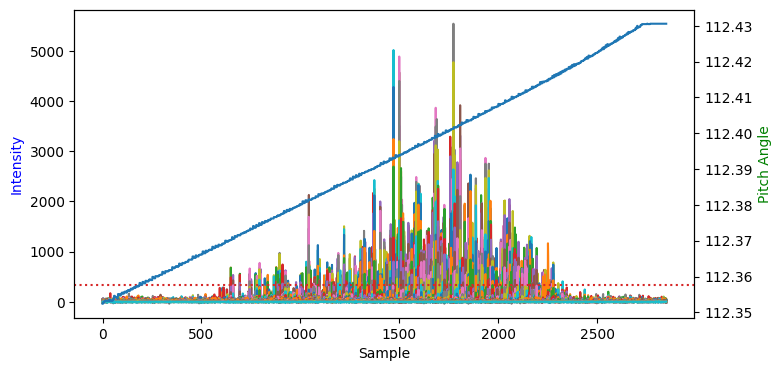

Monochromator 2 image found; 
Machine status file found: roll angle=1.7 deg 

tuff
['[1, 1, -1]', '[1, 1, 7]', '[2, 4, 2]', '[4, 2, 2]']
[array([-1, -1,  1]) array([-2, -4, -2]) array([-4, -2, -2])
 array([-1, -1, -7])]


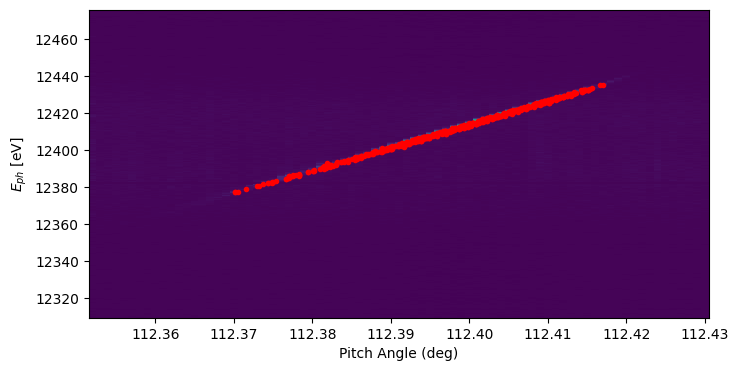

In [14]:
fidx = 9
tt = np.load(datafiles[fidx-1], allow_pickle=True)


fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()


thresh = tt['spec_hist'].max()/17

doocs_scale = tt['doocs_scale']
if len(doocs_scale) != len(orig_image):
    np_doocs=doocs_scale[:-1]
else:
    np_doocs=doocs_scale
#thresh = tt['spec_hist'].max()/6
ax1.plot(tt['spec_hist'])
ax1.axhline(thresh,ls=":",color='tab:red')
ax2.plot(tt['doocs_vals_hist'])

ax1.set_xlabel('Sample')
ax2.set_ylabel('Pitch Angle', color='g')
ax1.set_ylabel('Intensity', color='b')
#plt.xlim(16300, 16700)
plt.show()
filter_arr = []
seeding_energy = []
en = 0

x = tt['phen_scale']

pcentral = np.argmin(np.abs(x-Ecentral_orig))

x = dEdP_orig*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral_orig
np_phen = x
for spectrum in tt['spec_hist']:

    if np.max(spectrum) > thresh: ## Adjust this number to adjust threshold 
        filter_arr.append(True)
        seeding_energy.append(x[np.argmax(spectrum)]+en)
    else:
        filter_arr.append(False)


pitch = tt['doocs_vals_hist'][filter_arr]
seeding_energy_dict[str(fidx)] = seeding_energy
pitch_dict[str(fidx)] = pitch
pitches = pitch
Eph_seed = np.array(seeding_energy_dict[str(fidx)])#np.array(seeding_energy_dict
try:
    roll = roll_dict[str(fidx)]
    Hquery = Hquery_dict[str(fidx)]
    Hqueryd = Hqueryd_dict[str(fidx)]
except:
    roll = roll_in_database(datafiles[fidx-1])
    _, _, Hquery = getlocal_Hplanes(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
    _, _, Hqueryd = getlocal_Hplanes_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
print(Hquery)
print(Hqueryd)
# Plot extracted lines
# seeding_energy = seeding_energy_dict[str(fidx)]
# pitch = pitch_dict[str(fidx)]
fig, ax = plt.subplots(figsize=(8,4))

plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')
plt.plot(pitch, seeding_energy, 'r.')
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.show()


/tmp/ipykernel_21158/842142149.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]


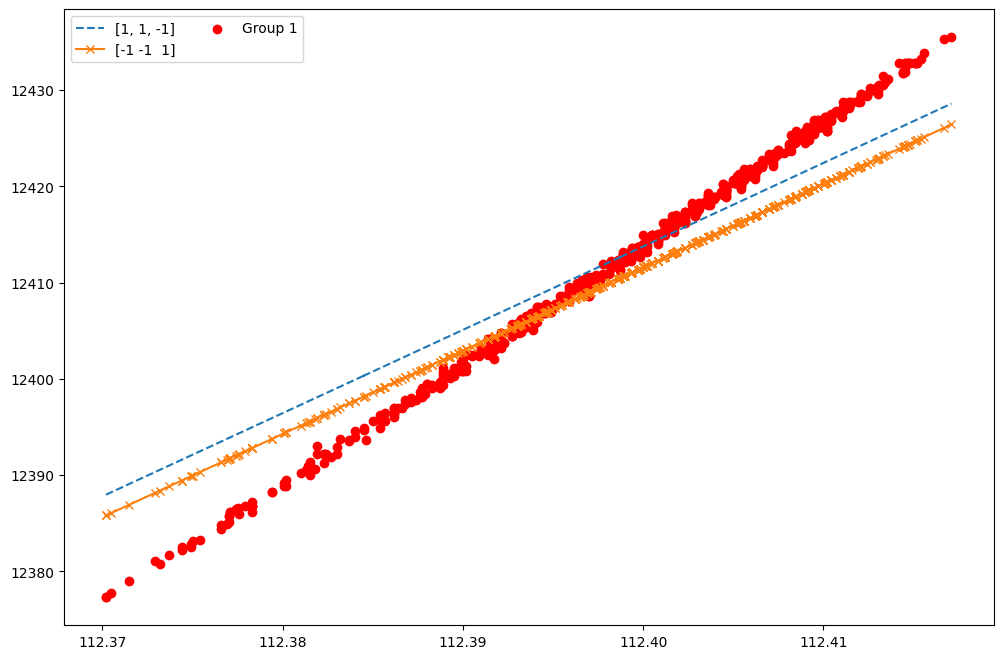

In [15]:
pitches_H = [pitches]#pitch#
Eoffset_pre = 0#20
E_H = [Eph_seed]#np.array
HtoMeas = [0,None,None,None]
HtoMeasd = [0,None,None,None]
#HtoMeas = [None,2,None,0,None,1]
fig, ax = plt.subplots(figsize=(12,8))
#ax.scatter(pitches,seeding_energy,color='red')

for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    if lidx is not None:
        Hd = Hqueryd[np.asarray(HtoMeasd)==lidx][0]   
        pitchi = pitches_H[lidx]
        E_Hi = E_H[lidx]
     
        EBragg,linestyle = HXRSS_singleLine(json.loads(H),pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBraggd = HXRSS_singleLine_ddiff(Hd,pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.asarray(EBragg) + Ecorrguess
        EBraggd = np.asarray(EBraggd) + Ecorrguess
        if pitchi.size>0:
            plt.plot(pitchi,EBragg,linestyle=linestyle,label=H)
            plt.plot(pitchi,EBraggd,'-x',label=f"{Hd}")

            ax.scatter(pitchi,E_Hi,color=group_colors[lidx],label=group_labels[lidx])
#plt.scatter(pitches,Eph_seed,color='red',s=1)
plt.legend(ncols=2)

In [16]:
pitch_acc += pitches_H
roll_acc += [roll]*len(pitches_H)
E_H_acc += E_H
Hquery_acc += [H for H,l in zip(Hquery,HtoMeas) if l is not None]
Hqueryd_acc += [H for H,l in zip(Hqueryd,HtoMeasd) if l is not None]
ncur = len(HtoMeas_acc)
HtoMeas_acc += [Htol + ncur for Htol in HtoMeas if Htol is not None]
HtoMeasd_acc += [Htol + ncur for Htol in HtoMeasd if Htol is not None]


### scan #14

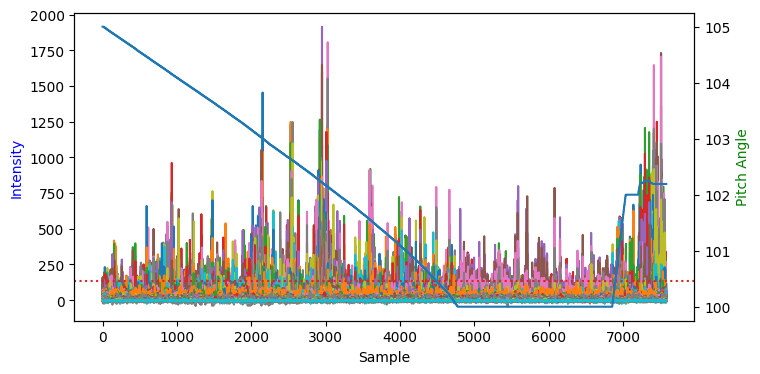

Monochromator 2 image found; 
Machine status file found: roll angle=1.7 deg 

tuff
['[0, 2, -6]', '[0, 4, 4]', '[1, -3, 3]', '[1, 1, 7]', '[1, 3, 1]', '[2, 0, -6]', '[2, 2, -4]', '[3, -1, -3]', '[3, 1, 1]', '[3, 3, 3]', '[3, 3, 5]', '[4, 0, 4]'] [array([-1, -3, -1]) array([-3, -1, -1]) array([-3,  1,  3])
 array([-1,  3, -3]) array([-2, -2,  4]) array([-3, -3, -3])
 array([ 0, -4, -4]) array([-4,  0, -4]) array([ 0, -2,  6])
 array([-2,  0,  6]) array([-1, -1, -7])]


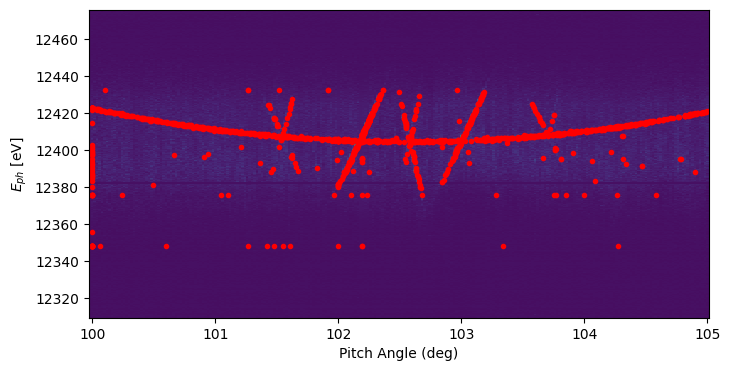

In [17]:
fidx = 14
tt = np.load(datafiles[fidx-1], allow_pickle=True)


fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()


thresh = tt['spec_hist'].max()/14

doocs_scale = tt['doocs_scale']
if len(doocs_scale) != len(orig_image):
    np_doocs=doocs_scale[:-1]
else:
    np_doocs=doocs_scale
#thresh = tt['spec_hist'].max()/6
ax1.plot(tt['spec_hist'])
ax1.axhline(thresh,ls=":",color='tab:red')
ax2.plot(tt['doocs_vals_hist'])

ax1.set_xlabel('Sample')
ax2.set_ylabel('Pitch Angle', color='g')
ax1.set_ylabel('Intensity', color='b')
#plt.xlim(16300, 16700)
plt.show()
filter_arr = []
seeding_energy = []
en = 0

x = tt['phen_scale']

pcentral = np.argmin(np.abs(x-Ecentral_orig))

x = dEdP_orig*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral_orig
np_phen = x
for spectrum in tt['spec_hist']:

    if np.max(spectrum) > thresh: ## Adjust this number to adjust threshold 
        filter_arr.append(True)
        seeding_energy.append(x[np.argmax(spectrum)]+en)
    else:
        filter_arr.append(False)


pitch = tt['doocs_vals_hist'][filter_arr]
seeding_energy_dict[str(fidx)] = seeding_energy
pitch_dict[str(fidx)] = pitch
pitches = pitch
Eph_seed = np.array(seeding_energy_dict[str(fidx)])#np.array(seeding_energy_dict
try:
    roll = roll_dict[str(fidx)]
    Hquery = Hquery_dict[str(fidx)]
    Hqueryd = Hqueryd_dict[str(fidx)]
    
except:
    roll = roll_in_database(datafiles[fidx-1])
    _, _, Hquery = getlocal_Hplanes(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
    _, _, Hqueryd = getlocal_Hplanes_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
print(Hquery,Hqueryd)
# Plot extracted lines
# seeding_energy = seeding_energy_dict[str(fidx)]
# pitch = pitch_dict[str(fidx)]
fig, ax = plt.subplots(figsize=(8,4))

plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')
plt.plot(pitch, seeding_energy, 'r.')
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.show()


In [18]:
HtoMeas = [3,2,4,0,None,7,6,9,None,5, None,8]
HtoMeasd = [None,None,9,4,6,5,2,8,3,7,0]

/tmp/ipykernel_21158/842142149.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]
/tmp/ipykernel_21158/3889838903.py:44: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitchi,EBraggd,linestyle=linestyle,marker='x',color=group_colors[lidx],label=-Hd)


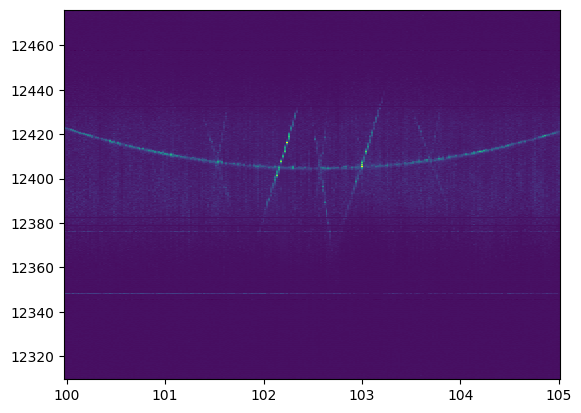

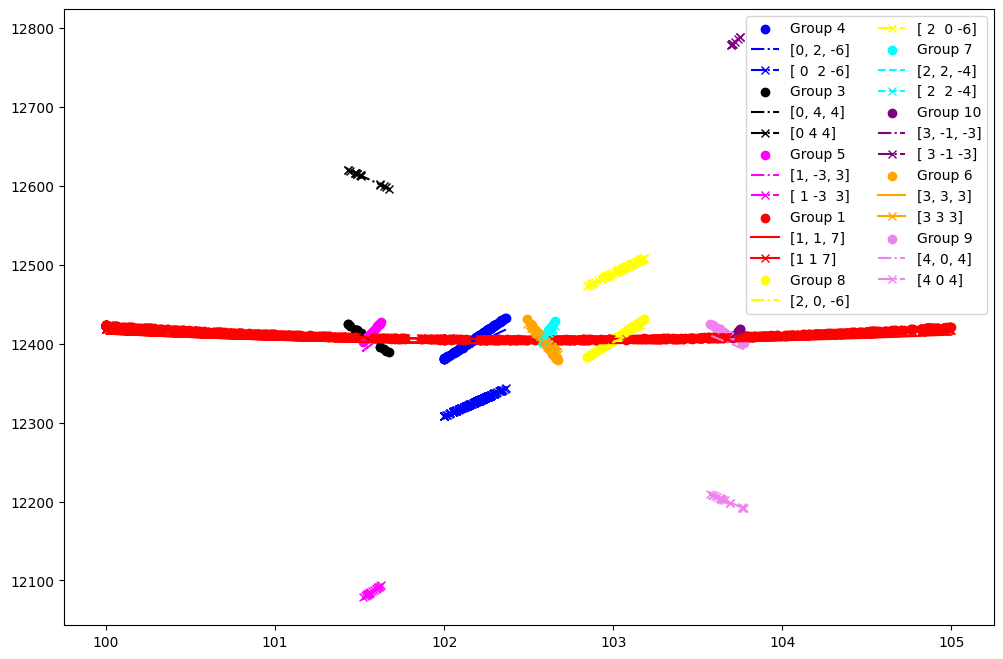

In [19]:
group_colors = ['red', 'green', 'black', 'blue', 'magenta','orange','cyan','yellow','violet','purple','gold','beige','aquamarine','wheat']  # Different colors for different groups
group_labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7','Group 8','Group 9','Group 10','Group 11','Group 12','Group 13','Group 14']
selected_points_by_group = {label: [] for label in group_labels}
selected_points_by_group["Group 1"] = np.unique([ [939, 940, 941, 942, 943, 944, 945, 946, 947, 948, 952, 953, 954, 955, 956, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 974, 975, 976, 977, 978, 979, 980, 981, 982, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099, 1100, 1101, 1102, 1103, 1104, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1124, 1125, 1126, 1127, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1146, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1157, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1170, 1172, 1173, 1174, 1176, 1177, 1178, 1180, 1182, 1183, 1184, 1185, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1204, 1205, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1227, 1228, 1229, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1245, 1246, 1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257, 1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1290, 1292, 1293, 1294, 1295, 1296, 1297, 1298, 1299, 1300, 1301, 1303, 1304, 1305, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1315, 1316, 1318, 1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1330, 1331, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1340, 1341, 1342, 1343, 1347, 1349, 1351, 1352, 1354, 1355, 1356, 1357, 1358, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370, 1374, 1375, 1376, 1378, 1379, 1380, 1381, 1382, 1383, 1384, 1385, 1386, 1387, 1389, 1390, 1391, 1393, 1395, 1397, 1398, 1399, 1400, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409, 1410, 1411, 1412, 1413, 1414, 1415, 1416, 1417, 1418, 1419, 1420, 1421, 1422, 1423, 1424, 1425, 1426, 1427, 1429, 1430, 1431, 1432, 1433, 1434, 1435, 1436, 1437, 1438, 1439, 1440, 1441, 1442, 1443, 1444, 1445, 1446, 1447, 1448, 1449, 1450, 1451, 1452, 1453, 1454, 1455, 1456, 1457, 1458, 1459, 1460, 1461, 1462, 1463, 1464, 1465, 1466, 1467, 1468, 1470, 1471, 1472, 1473, 1474, 1475, 1476, 1477, 1478, 1059, 1060, 1062, 1460, 1461, 925, 927, 928, 929, 930, 931, 932, 934, 935, 936, 937, 1479, 1480, 1481, 915, 916, 921, 923, 924, 925, 926, 927, 928, 929, 1481, 1482, 911, 915, 916, 921, 923, 1482, 1483, 855, 856, 858, 860, 861, 862, 865, 866, 874, 875, 877, 878, 879, 1488, 851, 852, 854, 855, 856, 858, 860, 861, 862, 865, 866, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851, 852, 1489, 839, 840, 841, 842, 843, 844, 845, 846, 834, 835, 1490, 819, 822, 823, 824, 825, 826, 827, 828, 831, 832, 833, 796, 797, 801, 802, 805, 806, 811, 812, 814, 816, 817, 1491, 1492, 1494, 1495, 1496, 1498, 1500, 1501, 1502, 1503, 1505, 1506, 1507, 1508, 1509, 1510, 1511, 1512, 1515, 1516, 1517, 1518, 1520, 1522, 784, 788, 792, 796, 797, 801, 802, 805, 806, 1522, 792, 796, 797, 801, 802, 805, 806, 811, 812, 814, 816, 1491, 1492, 1494, 1495, 1496, 1498, 1500, 1501, 1502, 1503, 1505, 1506, 1507, 1508, 1509, 1510, 1511, 1512, 1515, 1516, 1517, 1518, 1520, 1522, 802, 805, 806, 811, 812, 814, 816, 817, 818, 820, 1491, 1492, 1494, 1495, 1496, 1498, 1500, 1501, 1502, 1503, 1505, 1506, 1507, 1508, 1509, 1510, 1511, 1512, 1515, 1516, 1517, 1518, 1520, 772, 776, 777, 779, 784, 788, 792, 1522, 1527, 649, 651, 653, 654, 656, 657, 658, 661, 663, 665, 666, 673, 693, 1573, 1584, 1598, 1607, 673, 693, 701, 707, 708, 723, 1573, 1584, 1598, 1607, 693, 701, 707, 708, 723, 1547, 1551, 1555, 1573, 1584, 1598, 1607, 1611, 639, 649, 651, 652, 653, 654, 656, 657, 658, 661, 663, 665, 673, 627, 628, 629, 630, 631, 632, 633, 634, 637, 639, 633, 634, 637, 639, 649, 650, 651, 652, 653, 654, 656, 657, 620, 623, 624, 625, 626, 627, 628, 629, 613, 618, 619, 620, 531, 532, 533, 534, 536, 538, 539, 543, 548, 532, 533, 534, 536, 538, 539, 543, 548, 559, 560, 562, 563, 538, 539, 543, 548, 559, 560, 562, 563, 568, 572, 573, 575, 578, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 505, 507, 511, 512, 513, 514, 515, 516, 517, 518, 519, 493, 494, 495, 496, 501, 502, 504, 505, 507, 508, 511, 484, 485, 489, 490, 491, 493, 494, 495, 496, 462, 465, 466, 467, 468, 470, 473, 484, 485, 489, 490, 491, 493, 398, 420, 377, 381, 385, 389, 390, 396, 398, 363, 364, 365, 366, 367, 369, 370, 371, 372, 377, 381, 351, 354, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 348, 349, 350, 351, 352, 353, 354, 356, 357, 358, 359, 360, 361, 362, 334, 335, 336, 337, 338, 339, 340, 341, 342, 335, 336, 337, 338, 339, 340, 341, 342, 344, 345, 346, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 317, 318, 319, 320, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 297, 298, 299, 300, 302, 304, 305, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 273, 274, 275, 276, 279, 280, 282, 283, 286, 287, 288, 291, 293, 294, 295, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 252, 256, 257, 258, 259, 260, 214, 217, 218, 219, 220, 221, 223, 224, 225, 226, 227, 228, 229, 230, 231, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 223, 224, 225, 226, 227, 228, 218, 219, 220, 221, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 236, 196, 197, 198, 199, 200, 201, 202, 203, 205, 196, 197, 198, 199, 200, 201, 202, 203, 205, 206, 207, 208, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 211, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 211, 212, 213, 189, 190, 191, 192, 193, 194, 196, 197, 198, 176, 177, 178, 180, 181, 182, 183, 185, 186, 187, 188, 189, 155, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 173, 174, 149, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 173, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 143, 144, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 127, 128, 129, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 115, 116, 117, 118, 122, 123, 124, 125, 126, 127, 129, 133, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 17, 38, 39, 40, 41, 42, 43, 47, 48, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 115, 116, 117, 50, 51, 52, 37, 38, 39, 40, 41, 42, 43, 44, 47, 48, 49, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]]).tolist()
selected_points_by_group["Group 2"] = np.unique([1147, 1158, 1168, 1169, 1175, 1179, 1181, 1203, 1206, 1226, 1230, 1289, 1291, 1317, 1329, 1353, 1359, 1360, 1371, 1377, 1394, 1396, 1145, 1306, 1346, 1372, 1388, 1428]).tolist()
selected_points_by_group["Group 3"] = np.unique([918, 919, 920, 908, 909, 910, 912, 913, 903, 905, 906, 857, 859, 853, 867, 868]).tolist()
selected_points_by_group["Group 4"] = np.unique([635, 636, 638, 640, 641, 642, 643, 655, 659, 660, 664, 667, 668, 669, 670, 671, 672, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 691, 692, 694, 695, 696, 697, 698, 699, 700, 702, 703, 704, 705, 706, 709, 710, 711, 712, 713, 714, 716, 717, 718, 719, 720, 721, 722, 724, 725, 726, 727, 729, 730, 731, 733, 736, 739, 740, 741, 742, 743, 744, 745, 746, 749, 750, 751, 752, 753, 754, 756, 757, 758, 759, 760, 761, 762, 764, 765, 766, 767, 768, 769, 770, 771, 773, 775, 780, 781, 782, 783, 785, 786, 787, 789, 790, 791, 793, 794, 795, 798, 799, 800, 803, 804, 807, 809, 810, 813, 1497, 1499, 1504, 1514, 1519, 1521, 1523, 1524, 1525, 1526, 1528, 1529, 1530, 1531, 1534, 1535, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 1543, 1544, 1545, 1546, 1548, 1549, 1550, 1552, 1553, 1554, 1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564, 1565, 1566, 1567, 1568, 1569, 1570, 1571, 1572, 1574, 1575, 1576, 1577, 1578, 1579, 1580, 1581, 1582, 1583, 1585, 1586, 1587, 1588, 1589, 1590, 1591, 1593, 1594, 1595, 1596, 1597, 1599, 1600, 1601, 1602, 1603, 1604, 1605, 1606, 1608, 1609, 1610, 1612, 1614, 1615, 1616, 1617, 1618, 1619, 1620, 1621, 1622, 1623, 1624, 1625, 1626, 1627, 1629, 1635, 1637, 1638, 1651, 1657, 1659, 1669, 1672, 1684, 1695, 1699, 1706, 1707, 1709, 1712, 1722, 642, 643, 644, 645, 646, 647, 648, 728, 730, 731, 732, 733, 736, 737, 739, 1532, 1623, 1624, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661, 1662, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1675, 1676, 1678, 1679, 1680, 1682, 1683, 1684, 1685, 1686, 1687, 1688, 1689, 1691, 1692, 1695, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1709, 1710, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1719, 1720, 1721, 1722, 1723, 1724]).tolist()
selected_points_by_group["Group 5"] = np.unique([869, 870, 871, 872, 876, 880, 887, 1487, 863, 891, 901, 893, 896, 897, 885, 889, 891, 895, 1485, 863]).tolist()
selected_points_by_group["Group 6"] = np.unique([617, 615, 616, 612, 614, 609, 610, 611, 601, 602, 603, 604, 605, 606, 600, 601, 602, 603, 604, 605, 537, 540, 541, 542, 542, 544, 544, 546, 547, 549, 551, 552, 553, 555, 553, 558, 564, 567, 566, 567, 569, 570, 571, 574, 582, 571, 574, 576, 597, 598]).tolist()
selected_points_by_group["Group 7"] = np.unique([545, 550, 554, 556, 556, 557, 557, 561, 561, 565, 577, 579, 580, 581, 583, 584, 585, 588, 589, 590, 596, 588, 589, 590, 591, 592, 593]).tolist()
selected_points_by_group["Group 8"] = np.unique([373, 374, 375, 376, 378, 379, 380, 382, 383, 384, 386, 387, 388, 391, 392, 393, 394, 395, 397, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 421, 422, 423, 424, 425, 426, 427, 428, 429, 431, 432, 434, 435, 436, 437, 438, 439, 440, 441, 442, 461, 463, 469, 472, 475, 476, 478, 479, 480, 481, 482, 483, 486, 487, 488, 492, 497, 498, 499, 500, 503, 509, 510, 463, 469, 471, 472, 477, 460, 461, 463, 441, 442, 443, 444, 446, 447, 448, 443, 444, 446, 447, 448, 449]).tolist()
selected_points_by_group["Group 9"] = np.unique([301, 303, 306, 296, 289, 290, 292, 281, 284, 285, 277, 281, 270, 271, 272, 247, 249, 250, 251]).tolist()
selected_points_by_group["Group 10"] = np.unique([253, 254, 261, 262, 264, 265, 266, 267, 268, 269]).tolist()

pitches_H = []
E_H = []
plt.figure()
plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')
for lidx, points in enumerate(selected_points_by_group.values()):
    if(len(points)>0):
        pitches_H.append(pitches[points].squeeze())
        E_H.append(Eph_seed[points].squeeze())

HtoMeas = [3,2,4,0,None,7,6,9,None,5,None,8]
HtoMeasd = [None,None,9,4,6,5,2,8,3,7,0]
fig, ax = plt.subplots(figsize=(12,8))
#ax.scatter(pitches,seeding_energy,color='red')

for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    if lidx is not None:
        Hd = Hqueryd[np.asarray(HtoMeasd)==lidx][0]   
        pitchi = pitches_H[lidx]
        E_Hi = E_H[lidx]
     
        EBragg,linestyle = HXRSS_singleLine(json.loads(H),pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.array(EBragg) + Ecorrguess
        EBraggd = HXRSS_singleLine_ddiff(Hd,pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.asarray(EBragg) + Ecorrguess
        EBraggd = np.asarray(EBraggd) + Ecorrguess
        if pitchi.size>0:
            ax.scatter(pitchi,E_Hi,color=group_colors[lidx],label=group_labels[lidx])
            plt.plot(pitchi,EBragg,linestyle=linestyle,color=group_colors[lidx],label=H)
            plt.plot(pitchi,EBraggd,linestyle=linestyle,marker='x',color=group_colors[lidx],label=-Hd)
#plt.scatter(pitches,Eph_seed,color='red',s=1)
plt.legend(ncols=2)



In [ ]:
# Automated manual-selection sanity check
# This compares image-only peak/ridge candidates with the hand-selected groups above.
automation_result = run_automation_sanity_check(
    tt=tt,
    fidx=fidx,
    selected_points_by_group=selected_points_by_group,
    pitches=pitches,
    Eph_seed=Eph_seed,
    roll=roll,
    HtoMeas=HtoMeas,
    Hquery=Hquery,
    HtoMeasd=HtoMeasd,
    Hqueryd=Hqueryd,
    energy_axis=np_phen,
    angle_axis=tt["doocs_vals_hist"],
    np_doocs=np_doocs,
    energy_tolerance=10.0,
    plot=True,
)


In [20]:
pitch_acc += pitches_H
roll_acc += [roll]*len(pitches_H)
E_H_acc += E_H
Hquery_acc += [H for H,l in zip(Hquery,HtoMeas) if l is not None]
Hqueryd_acc += [H for H,l in zip(Hqueryd,HtoMeasd) if l is not None]
ncur = len(HtoMeas_acc)
HtoMeas_acc += [Htol + ncur for Htol in HtoMeas if Htol is not None]
HtoMeasd_acc += [Htol + ncur for Htol in HtoMeasd if Htol is not None]


In [ ]:
HtoMeas_acc


[2, 0, 1, 3, 7, 6, 8, 4, 11, 10, 13, 9, 12]

## scan #16

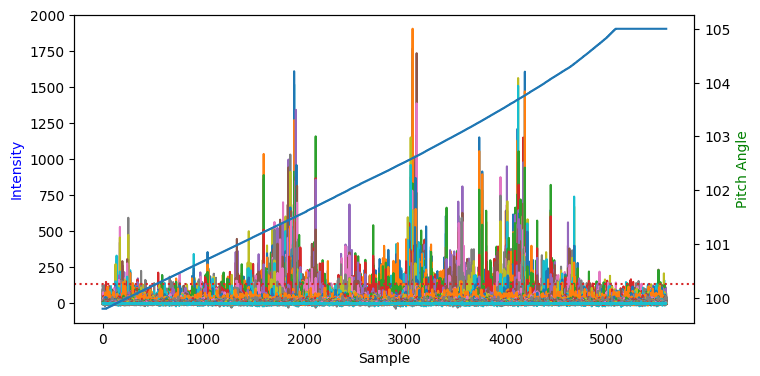

Monochromator 2 image found; 
Machine status file found: roll angle=0.4 deg 

tuff
['[0, 2, -6]', '[0, 4, 4]', '[1, -3, 3]', '[1, 1, 7]', '[1, 3, 1]', '[2, 0, -6]', '[2, 2, -4]', '[3, -1, -5]', '[3, -1, -3]', '[3, 1, -3]', '[3, 1, 1]', '[3, 3, 3]', '[3, 3, 5]', '[4, 0, 4]']
[array([1, 3, 1]) array([3, 1, 1]) array([ 3, -1, -3]) array([ 1, -3,  3])
 array([ 2,  2, -4]) array([3, 3, 3]) array([0, 4, 4]) array([4, 0, 4])
 array([ 0,  2, -6]) array([ 2,  0, -6]) array([1, 1, 7])]


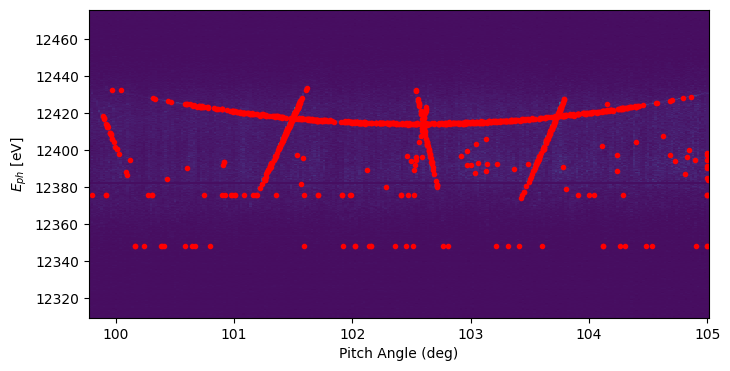

In [21]:
fidx = 16
tt = np.load(datafiles[fidx-1], allow_pickle=True)


fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()


thresh = tt['spec_hist'].max()/14

doocs_scale = tt['doocs_scale']
if len(doocs_scale) != len(orig_image):
    np_doocs=doocs_scale[:-1]
else:
    np_doocs=doocs_scale
#thresh = tt['spec_hist'].max()/6
ax1.plot(tt['spec_hist'])
ax1.axhline(thresh,ls=":",color='tab:red')
ax2.plot(tt['doocs_vals_hist'])

ax1.set_xlabel('Sample')
ax2.set_ylabel('Pitch Angle', color='g')
ax1.set_ylabel('Intensity', color='b')
#plt.xlim(16300, 16700)
plt.show()
filter_arr = []
seeding_energy = []
en = 0

x = tt['phen_scale']

pcentral = np.argmin(np.abs(x-Ecentral_orig))

x = dEdP_orig*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral_orig
np_phen = x
for spectrum in tt['spec_hist']:

    if np.max(spectrum) > thresh: ## Adjust this number to adjust threshold 
        filter_arr.append(True)
        seeding_energy.append(x[np.argmax(spectrum)]+en)
    else:
        filter_arr.append(False)


pitch = tt['doocs_vals_hist'][filter_arr]
seeding_energy_dict[str(fidx)] = seeding_energy
pitch_dict[str(fidx)] = pitch
pitches = pitch
Eph_seed = np.array(seeding_energy_dict[str(fidx)])#np.array(seeding_energy_dict
try:
    roll = roll_dict[str(fidx)]
    Hquery = Hquery_dict[str(fidx)]
    Hqueryd = Hqueryd_dict[str(fidx)]
except:
    roll = roll_in_database(datafiles[fidx-1])
    _, _, Hquery = getlocal_Hplanes(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
    _, _, Hqueryd = getlocal_Hplanes_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
print(Hquery)
print(-Hqueryd)
# Plot extracted lines
# seeding_energy = seeding_energy_dict[str(fidx)]
# pitch = pitch_dict[str(fidx)]
fig, ax = plt.subplots(figsize=(8,4))

plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')
plt.plot(pitch, seeding_energy, 'r.')
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.show()


0 : [36, 42, 44, 48, 50, 52, 53, 56, 58, 60, 62, 64, 66, 68, 71, 74, 76, 78, 79, 82, 88, 91, 94, 96, 98, 102, 103, 105, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 136, 137, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 154, 155, 157, 158, 165, 178, 179, 180, 184, 185, 188, 191, 192, 193, 195, 198, 200, 201, 202, 206, 207, 209, 211, 227, 296, 301, 310, 314, 317, 318, 319, 323, 325, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 394, 395, 396, 398, 399, 400, 401, 402, 403, 404, 405, 406, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 438, 439, 443, 444, 445, 

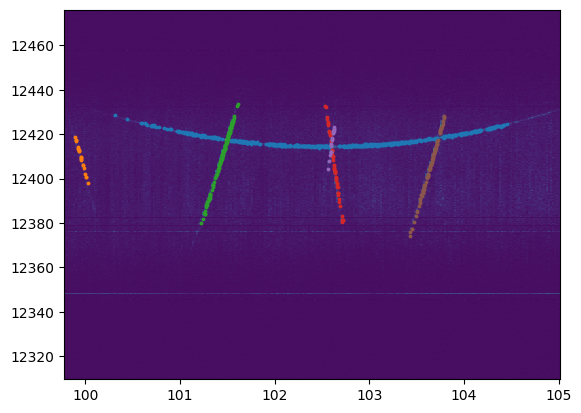

/tmp/ipykernel_21158/842142149.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]
/tmp/ipykernel_21158/2340139299.py:46: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitchi,EBraggd,'-x',color=group_colors[lidx],label=-Hd)


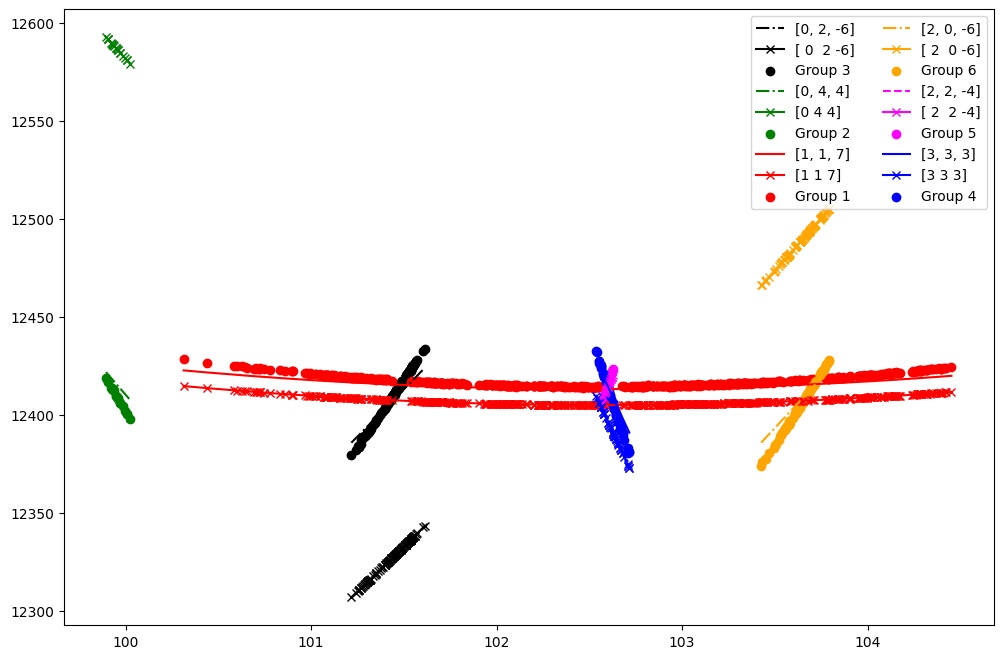

In [22]:
group_colors = ['red', 'green', 'black', 'blue', 'magenta','orange','cyan','yellow','violet','purple','gold','beige','aquamarine','wheat']  # Different colors for different groups
group_labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7','Group 8','Group 9','Group 10','Group 11','Group 12','Group 13','Group 14']
selected_points_by_group = {label: [] for label in group_labels}
selected_points_by_group["Group 1"] = np.unique([36, 42, 44, 48, 50, 52, 53, 56, 58, 60, 62, 64, 66, 68, 71, 74, 76, 78, 79, 82, 88, 91, 94, 96, 98, 102, 103, 105, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 136, 137, 139, 140, 141, 142, 143, 144, 146, 147, 148, 149, 154, 155, 157, 158, 165, 178, 179, 180, 184, 185, 188, 191, 192, 193, 195, 198, 200, 201, 202, 206, 207, 209, 211, 195, 198, 200, 201, 202, 206, 207, 209, 211, 227, 296, 301, 310, 314, 317, 318, 319, 323, 325, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 394, 395, 396, 398, 399, 400, 401, 402, 403, 404, 405, 406, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 438, 439, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 482, 483, 484, 485, 486, 489, 490, 491, 492, 493, 494, 496, 497, 499, 500, 503, 504, 505, 506, 508, 510, 512, 514, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 493, 494, 496, 497, 499, 500, 501, 503, 504, 505, 506, 508, 510, 512, 503, 504, 505, 506, 508, 510, 512, 514, 515, 517, 522, 523, 524, 525, 526, 527, 510, 512, 514, 515, 517, 522, 523, 524, 525, 526, 527, 535, 536, 543, 605, 608, 610, 616, 617, 618, 619, 620, 621, 622, 623, 625, 626, 627, 628, 629, 630, 631, 632, 633, 635, 636, 637, 638, 640, 641, 642, 643, 644, 645, 646, 647, 648, 649, 650, 651, 652, 653, 655, 656, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670, 671, 673, 675, 676, 677, 678, 679, 681, 682, 683, 684, 685, 686, 687, 688, 689, 691, 692, 693, 695, 696, 697, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 718, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 738, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 774, 775, 776, 777, 778, 780, 781, 783, 784, 786, 787, 788, 789, 792, 793, 795, 797, 798, 800, 803, 804, 806, 808, 812, 826, 828, 830, 831, 834, 843, 844, 845, 848, 857, 866, 843, 844, 845, 848, 857, 866, 844, 845, 848, 857, 866, 877, 848, 857, 866, 877, 857, 866, 877, 881, 882, 911, 912, 913, 917, 918, 920, 921, 924, 926, 927, 928, 929, 930, 931, 932, 933, 930, 931, 932, 933, 934, 935, 936, 937, 938, 939, 941, 942, 943, 944, 945, 946, 947, 948, 949, 950, 951, 952, 953, 954, 955, 956, 953, 954, 955, 956, 957, 959, 960, 961, 962, 963, 964, 965, 966, 968, 966, 968, 969, 970, 971, 972, 973, 974, 975, 977, 978, 979, 972, 973, 974, 975, 977, 978, 979, 982, 983, 984, 985, 986, 987, 989, 990, 974, 975, 977, 978, 979, 982, 983, 984, 985, 986, 987, 989, 990, 991, 992, 993, 1002, 1003, 1004, 1005, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1015, 1016, 1017, 1019, 1020, 1021, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1028, 1034, 1035, 1036, 1034, 1035, 1036, 1037, 1027, 1028, 1029, 1030, 1031, 1033]).tolist()
selected_points_by_group["Group 2"] = np.unique([1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25]).tolist()
selected_points_by_group["Group 3"] = np.unique([138, 145, 150, 151, 152, 153, 156, 159, 160, 161, 162, 163, 164, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 181, 182, 183, 186, 187, 190, 194, 196, 197, 199, 203, 204, 205, 208, 210, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 254, 257, 258, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 283, 284, 285, 286, 287, 288, 289, 291, 292, 293, 294, 295, 297, 298, 299, 300, 302, 303, 304, 305, 306, 307, 308, 309, 311, 312, 315, 316, 324, 326, 246, 248, 249, 250, 251, 254, 257, 258, 259, 251, 254, 257, 258, 259, 260, 261, 262, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268]).tolist()
selected_points_by_group["Group 4"] = np.unique([518, 520, 528, 529, 530, 531, 532, 533, 537, 538, 540, 612, 613, 614, 615, 611, 609, 606, 607, 600, 602, 603, 604, 596, 597, 598, 599, 601, 590, 591, 592, 593, 582, 583, 584, 585, 586, 575, 577, 578, 580, 581, 575, 577, 569, 561, 563, 564, 566, 540, 541, 542, 546, 555, 556, 558]).tolist()
selected_points_by_group["Group 5"] = np.unique([571, 572, 573, 572, 573, 574, 567, 568, 567, 568, 570, 571, 572, 573, 559, 560, 562, 539, 534, 544, 547, 548, 550, 552, 553, 547, 548, 549]).tolist()
selected_points_by_group["Group 6"] = np.unique([858, 859, 860, 861, 794, 782, 785, 790, 791, 794, 799, 801, 802, 805, 807, 809, 810, 811, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 827, 829, 832, 835, 836, 837, 838, 839, 840, 841, 842, 846, 847, 849, 850, 851, 852, 853, 854, 855, 856, 858, 859, 860, 861, 862, 863, 864, 865, 867, 868, 869, 870, 871, 872, 873, 874, 875, 876, 878, 879, 880, 883, 884, 813, 814, 815, 816, 818, 919, 922, 923, 914, 915, 919, 922, 910, 914, 915, 905, 906, 907, 908, 909, 910, 896, 898, 899, 900, 901, 902, 904, 905, 906, 907, 879, 880, 883, 884, 885, 883, 884, 885, 886, 885, 886, 887, 891]).tolist()


pitches_H = []
E_H = []
plt.figure()
plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')

for lidx, points in enumerate(selected_points_by_group.values()):
    if len(points)>0:
        pitches_H.append(pitches[points].squeeze())
        E_H.append(Eph_seed[points].squeeze())
        print(lidx,':',points)
        # print(lidx,':',pitches_H[lidx],'\n',E_H[lidx])
        plt.scatter(pitches_H[lidx],E_H[lidx],s=3)
plt.show()

HtoMeas = [2,1,None,0,None,5,4,None,None,None,None,3,None,None]
HtoMeasd = [None,None,None,None,4,3,1,None,2,5,0]
fig, ax = plt.subplots(figsize=(12,8))
#ax.scatter(pitches,seeding_energy,color='red')

for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    if lidx is not None:
        Hd = Hqueryd[np.asarray(HtoMeasd)==lidx][0]
        pitchi = pitches_H[lidx]
        E_Hi = E_H[lidx]
     
        EBragg,linestyle = HXRSS_singleLine(json.loads(H),pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.asarray(EBragg) + Ecorrguess
        EBraggd = HXRSS_singleLine_ddiff(Hd,pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBraggd = np.asarray(EBraggd) + Ecorrguess

        
        if pitchi.size>0:
            plt.plot(pitchi,EBragg,linestyle=linestyle,color=group_colors[lidx],label=H)
            plt.plot(pitchi,EBraggd,'-x',color=group_colors[lidx],label=-Hd)
            ax.scatter(pitchi,E_Hi,color=group_colors[lidx],label=group_labels[lidx])
#plt.scatter(pitches,Eph_seed,color='red',s=1)
plt.legend(ncols=2)

In [ ]:
# Automated manual-selection sanity check
# This compares image-only peak/ridge candidates with the hand-selected groups above.
automation_result = run_automation_sanity_check(
    tt=tt,
    fidx=fidx,
    selected_points_by_group=selected_points_by_group,
    pitches=pitches,
    Eph_seed=Eph_seed,
    roll=roll,
    HtoMeas=HtoMeas,
    Hquery=Hquery,
    HtoMeasd=HtoMeasd,
    Hqueryd=Hqueryd,
    energy_axis=np_phen,
    angle_axis=tt["doocs_vals_hist"],
    np_doocs=np_doocs,
    energy_tolerance=10.0,
    plot=True,
)


In [23]:
HtoMeas = [2,1,None,0,None,5,4,None,None,None,None,3,None]


In [ ]:
ncur = len(pitch_acc)
pitch_acc += pitches_H
roll_acc += [roll]*len(pitches_H)
E_H_acc += E_H
Hquery_acc += [H for H,l in zip(Hquery,HtoMeas) if l is not None]
HtoMeas_acc += [Htol + ncur for Htol in HtoMeas if Htol is not None]
Hqueryd_acc += [H for H,l in zip(Hqueryd,HtoMeasd) if l is not None]
HtoMeasd_acc += [Htol + ncur for Htol in HtoMeasd if Htol is not None]


## scan #18 (80°)

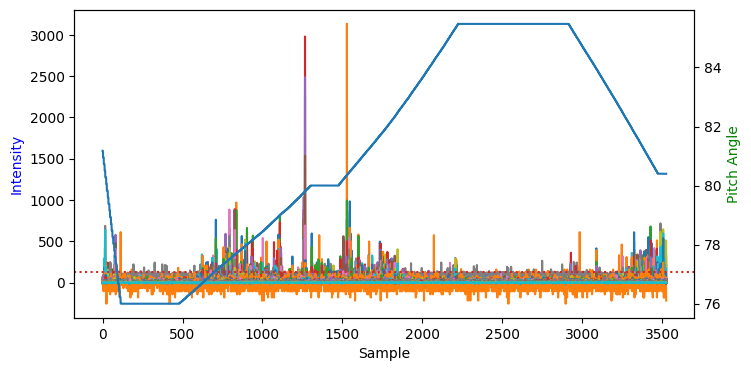

Monochromator 2 image found; 
Machine status file found: roll angle=0.4 deg 

tuff
['[0, 2, 6]', '[0, 4, -4]', '[1, -3, -5]', '[1, -3, -3]', '[1, -3, 5]', '[1, -1, -7]', '[1, 1, -7]', '[1, 3, -1]', '[1, 3, 3]', '[1, 3, 5]', '[2, 0, 6]', '[2, 2, 4]', '[3, -1, 3]', '[3, -1, 5]', '[3, 1, -1]', '[3, 1, 3]', '[3, 3, -5]', '[3, 3, -3]', '[4, 0, -4]']
[array([-1, -3,  1]) array([-3, -1,  1]) array([-3, -1, -3])
 array([-1,  3,  3]) array([-1, -3, -3]) array([-3,  1, -3])
 array([-2, -2, -4]) array([-3, -3,  3]) array([-4,  0,  4])
 array([ 0, -4,  4]) array([-1,  3, -5]) array([-1,  3,  5])
 array([-3,  1, -5]) array([ 0, -2, -6]) array([-2,  0, -6])
 array([-3, -3,  5]) array([-1, -1,  7]) array([-1,  1,  7])]


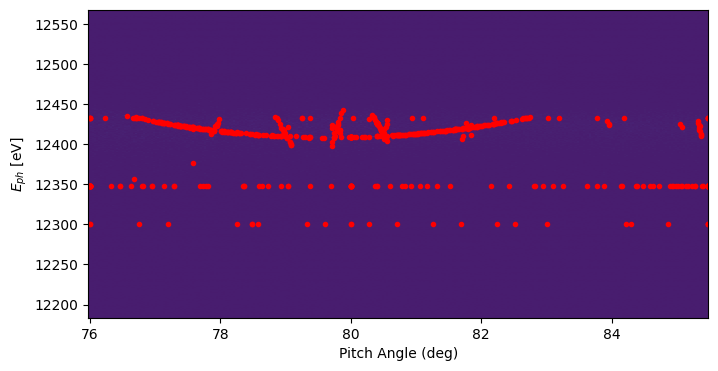

In [ ]:
fidx = 18
tt = np.load(datafiles[fidx-1], allow_pickle=True)


fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()


thresh = tt['spec_hist'].max()/25

doocs_scale = tt['doocs_scale']
if len(doocs_scale) != len(orig_image):
    np_doocs=doocs_scale[:-1]
else:
    np_doocs=doocs_scale
#thresh = tt['spec_hist'].max()/6
ax1.plot(tt['spec_hist'])
ax1.axhline(thresh,ls=":",color='tab:red')
ax2.plot(tt['doocs_vals_hist'])

ax1.set_xlabel('Sample')
ax2.set_ylabel('Pitch Angle', color='g')
ax1.set_ylabel('Intensity', color='b')
#plt.xlim(16300, 16700)
plt.show()
filter_arr = []
seeding_energy = []
en = 0

x = tt['phen_scale']

pcentral = np.argmin(np.abs(x-Ecentral_orig))

x = dEdP_orig*np.arange(-pcentral,-pcentral+tt['phen_scale'].size) + Ecentral_orig
np_phen = x
for spectrum in tt['spec_hist']:

    if np.max(spectrum) > thresh: ## Adjust this number to adjust threshold 
        filter_arr.append(True)
        seeding_energy.append(x[np.argmax(spectrum)]+en)
    else:
        filter_arr.append(False)


pitch = tt['doocs_vals_hist'][filter_arr]
seeding_energy_dict[str(fidx)] = seeding_energy
pitch_dict[str(fidx)] = pitch
pitches = pitch
Eph_seed = np.array(seeding_energy_dict[str(fidx)])#np.array(seeding_energy_dict
try:
    roll = roll_dict[str(fidx)]
    Hquery = Hquery_dict[str(fidx)]
    Hqueryd = Hqueryd_dict[str(fidx)]
except:
    roll = roll_in_database(datafiles[fidx-1])
    _, _, Hquery = getlocal_Hplanes(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
    _, _, Hqueryd = getlocal_Hplanes_ddiff(hmax, kmax, lmax, dthp, dthy, dthr, alpha, roll,np_phen,np_doocs)
print(Hquery)
print(Hqueryd)
# Plot extracted lines
# seeding_energy = seeding_energy_dict[str(fidx)]
# pitch = pitch_dict[str(fidx)]
fig, ax = plt.subplots(figsize=(8,4))

plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')
plt.plot(pitch, seeding_energy, 'r.')
ax.set_xlabel('Pitch Angle (deg)')
ax.set_ylabel(r'$E_{ph}$ [eV]')
plt.show()


In [26]:
np.all(Hqueryd[0] == json.loads(Hquery[1]))

False

In [27]:
HtoMeas = [2,1,None,None,None,None,0,None,None,None,4,None,None,None,None,7,None,None,None]
HtoMeasd = np.ones(len(Hqueryd),dtype=int)*np.nan
resort_idx = np.array([np.argmin([np.sum(np.abs(np.asarray(-Hd)-np.asarray(json.loads(H)))) for Hd in Hqueryd]) for H in Hquery])
HtoMeasd[resort_idx] = np.asarray(HtoMeas)
HtoMeasd = [None if np.isnan(lidx) else int(lidx) for lidx in HtoMeasd ]


0 : [0, 1, 3, 6, 7, 11, 13, 14, 15, 19, 24, 26, 67, 68, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 140, 141, 142, 143, 145, 146, 147, 148, 149, 150, 152, 153, 154, 157, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 194, 195, 196, 197, 198, 199, 201, 202, 203, 204, 207, 209, 210, 211, 212, 214, 217, 220, 229, 242, 245, 246, 248, 249, 250, 253, 254, 262, 263, 274, 277, 279, 284, 286, 287, 288, 289, 293, 294, 295, 297, 298, 300, 301, 303, 304, 306, 308, 309, 312, 313, 314, 315, 328, 334, 335, 339, 340, 345, 346, 347, 348, 350, 351, 352, 353, 354, 355, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 374, 375, 376, 378, 379, 

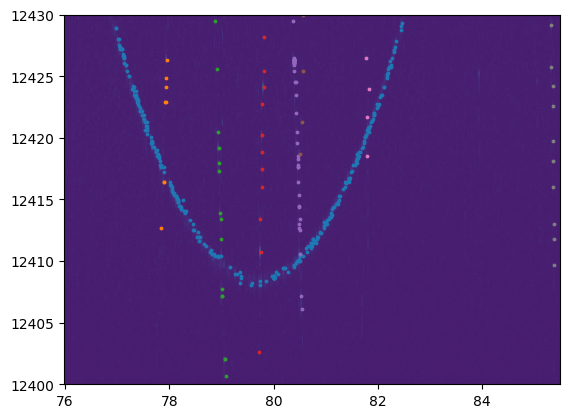

/tmp/ipykernel_21158/842142149.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]
/tmp/ipykernel_21158/1265158166.py:43: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitchi,EBraggd,'-x',label=-Hd,color=group_colors[lidx])


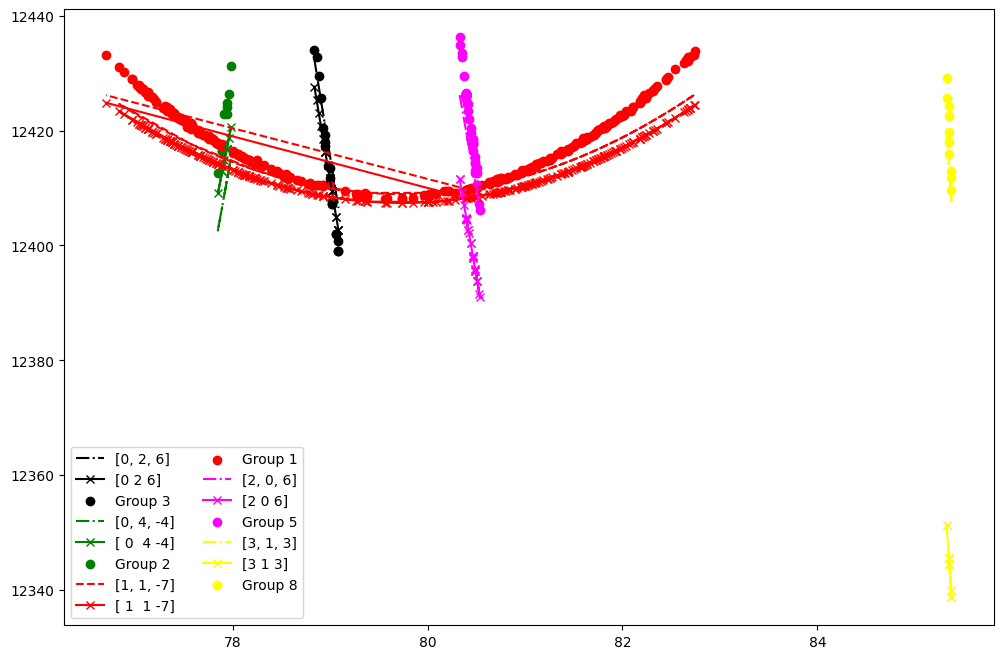

In [28]:
selected_points_by_group['Group 1'] = [0, 1, 3, 6, 7, 11, 13, 14, 15, 19, 24, 26, 67, 68, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 92, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 137, 138, 140, 141, 142, 143, 145, 146, 147, 148, 149, 150, 152, 153, 154, 157, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 194, 195, 196, 197, 198, 199, 201, 202, 203, 204, 207, 209, 210, 211, 212, 214, 217, 220, 229, 242, 245, 246, 248, 249, 250, 253, 254, 262, 263, 274, 277, 279, 284, 286, 287, 288, 289, 293, 294, 295, 297, 298, 300, 301, 303, 304, 306, 308, 309, 312, 313, 314, 315, 328, 334, 335, 339, 340, 345, 346, 347, 348, 350, 351, 352, 353, 354, 355, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 374, 375, 376, 378, 379, 380, 381, 382, 384, 385, 387, 388, 391, 392, 393, 395, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 409, 410, 411, 412, 414, 415, 416, 417, 418, 419, 420, 422, 423, 424, 425, 426, 427, 515, 516, 517, 518, 519, 521, 522, 523, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 536, 537, 538, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 559, 560, 561, 562, 563, 565, 567, 569, 570, 571, 572, 573, 576, 577, 579, 580, 581, 582, 585, 593, 597, 615, 627, 57]
selected_points_by_group['Group 2'] = [158, 159, 160, 161, 162, 163, 151, 155, 156]
selected_points_by_group['Group 3'] = [213, 215, 216, 218, 221, 222, 223, 224, 226, 227, 228, 230, 231, 232, 237, 238, 239, 240, 241]
selected_points_by_group['Group 4'] = [273, 272, 271, 270, 269, 268, 267, 266, 265, 261, 264, 260]
selected_points_by_group['Group 5'] = [318, 317, 320, 319, 321, 324, 325, 596, 598, 602, 604, 606, 607, 609, 610, 611, 618, 621, 628, 599, 600, 601, 603, 605, 612, 613, 614, 616, 617, 619, 620, 622, 623, 624, 625, 626, 629, 630, 326, 595, 327, 594, 329, 330, 333, 333, 592, 331, 332, 591, 590, 336, 589, 341, 337, 338, 588, 342, 340, 586]
selected_points_by_group['Group 6'] = [343, 344, 587, 4]
selected_points_by_group['Group 7'] = [389, 390, 535, 394]
selected_points_by_group['Group 8'] = [448, 449, 450, 451, 452, 453, 490, 491, 492, 493]
pitches_H = []
E_H = []
plt.figure()
plt.pcolormesh(np_doocs,np_phen ,tt['corr2d'].T,shading='auto')

for lidx, points in enumerate(selected_points_by_group.values()):
    if len(points)>0:
        pitches_H.append(pitches[points].squeeze())
        E_H.append(Eph_seed[points].squeeze())
        print(lidx,':',points)
        # print(lidx,':',pitches_H[lidx],'\n',E_H[lidx])
        plt.scatter(pitches_H[lidx],E_H[lidx],s=3)
plt.ylim(12400,12430)
plt.show()
#HtoMeas = [2,1,None,None,None,None,0,None,None,4,None,None,5,7,None,3,6]
#HtoMeas = [2,1,None,None,None,None,0,None,None,4,None,None,5,None,None,3,6]
#HtoMeas = [2,1,None,None,None,None,0,None,None,None,4,None,None,None,None,7,None,None,None]
fig, ax = plt.subplots(figsize=(12,8))
#ax.scatter(pitches,seeding_energy,color='red')

for Hidx, H in enumerate(Hquery):
    lidx = HtoMeas[Hidx]
    if lidx is not None:
        Hd = Hqueryd[np.asarray(HtoMeasd)==lidx][0]
        pitchi = pitches_H[lidx]
        E_Hi = E_H[lidx]
     
        EBragg,linestyle = HXRSS_singleLine(json.loads(H),pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.array(EBragg) + Ecorrguess
        EBraggd = HXRSS_singleLine_ddiff(Hd,pitchi,[roll],dPguess,dRguess,dYguess,dRPguess)
        EBraggd = np.asarray(EBraggd) + Ecorrguess

        if pitchi.size>0:
            plt.plot(pitchi,EBragg,linestyle=linestyle,label=H,color=group_colors[lidx])
            plt.plot(pitchi,EBraggd,'-x',label=-Hd,color=group_colors[lidx])
            ax.scatter(pitchi,E_Hi,color=group_colors[lidx],label=group_labels[lidx])
#plt.scatter(pitches,Eph_seed,color='red',s=1)
plt.legend(ncols=2)

In [ ]:
# Automated manual-selection sanity check
# This compares image-only peak/ridge candidates with the hand-selected groups above.
automation_result = run_automation_sanity_check(
    tt=tt,
    fidx=fidx,
    selected_points_by_group=selected_points_by_group,
    pitches=pitches,
    Eph_seed=Eph_seed,
    roll=roll,
    HtoMeas=HtoMeas,
    Hquery=Hquery,
    HtoMeasd=HtoMeasd,
    Hqueryd=Hqueryd,
    energy_axis=np_phen,
    angle_axis=tt["doocs_vals_hist"],
    np_doocs=np_doocs,
    energy_tolerance=10.0,
    plot=True,
)


In [29]:
ncur = len(pitch_acc)
pitch_acc += pitches_H
roll_acc += [roll]*len(pitches_H)
E_H_acc += E_H
Hquery_acc += [H for H,l in zip(Hquery,HtoMeas) if l is not None]
HtoMeas_acc += [Htol + ncur for Htol in HtoMeas if Htol is not None]
Hqueryd_acc += [H for H,l in zip(Hqueryd,HtoMeasd) if l is not None]
HtoMeasd_acc += [Htol + ncur for Htol in HtoMeasd if Htol is not None]

In [30]:
print(Hquery_acc)
print(HtoMeas_acc)

['[1, 1, -1]', '[2, 4, 2]', '[4, 2, 2]', '[1, 1, -1]', '[0, 2, -6]', '[0, 4, 4]', '[1, -3, 3]', '[1, 1, 7]', '[2, 0, -6]', '[2, 2, -4]', '[3, -1, -3]', '[3, 3, 3]', '[4, 0, 4]', '[0, 2, -6]', '[0, 4, 4]', '[1, 1, 7]', '[2, 0, -6]', '[2, 2, -4]', '[3, 3, 3]', '[0, 2, 6]', '[0, 4, -4]', '[1, 1, -7]', '[2, 0, 6]', '[3, 1, 3]']
[2, 0, 1, 3, 7, 6, 8, 4, 11, 10, 13, 9, 12, 16, 15, 14, 19, 18, 17, 22, 21, 20, 24, 27]


In [ ]:
print(Hquery_acc)

In [84]:
HtoMeas_acc = [2, 0, 1, 3, 7, 6, 8, 4, 11, 10, 13, 9, 12, 16, 15, 14, 19, 18, 17]#, 22, 21, 20, 24, 27]
Hquery_acc =['[1, 1, -1]', '[2, 4, 2]', '[4, 2, 2]', '[1, 1, -1]', '[0, 2, -6]', '[0, 4, 4]', '[1, -3, 3]', '[1, 1, 7]', '[2, 0, -6]', '[2, 2, -4]', '[3, -1, -3]', '[3, 3, 3]', '[4, 0, 4]', '[0, 2, -6]', '[0, 4, 4]', '[1, 1, 7]', '[2, 0, -6]', '[2, 2, -4]', '[3, 3, 3]']#, '[0, 2, 6]', '[0, 4, -4]', '[1, 1, -7]', '[2, 0, 6]', '[3, 1, 3]']
#,
#  '[0, 2, 6]',
#  '[0, 4, -4]',
#  '[1, 1, -7]',
#  '[2, 0, 6]',
#  '[3, 3, -3]',]

## plot lines together

/tmp/ipykernel_7587/3948502776.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(H=Hplane)[1]
/tmp/ipykernel_7587/1922125495.py:21: MatplotlibDeprecationWarning: Passing label as a length 3 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(pitch_list,EBragg,label=H)


(12098.2, 12682.8)

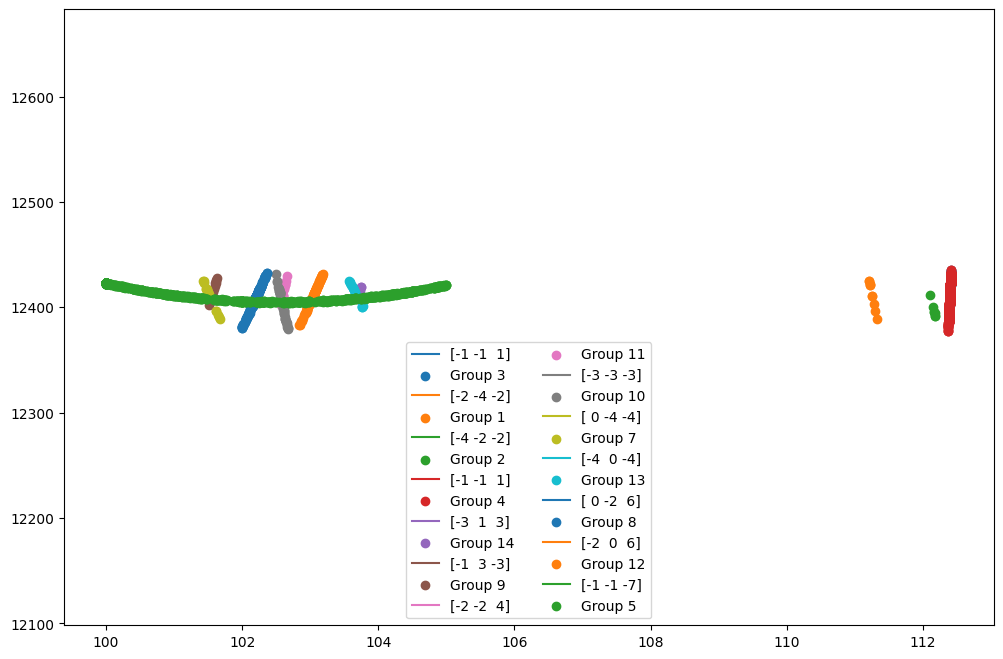

In [64]:
# dPconv, dRconv, dYconv, dRPconv, Ecorrconv =  [2.41322609e+00, -5.00000000e+00, -9.33453740e+00, -9.44353028e-03,  4.65311758e+01]
# dPconv, dRconv, dYconv, dRPconv, Ecorrconv = [1.15235012e+00,  6.04787206e-02,  9.34291663e-01, -1.39320701e-02, -1.63462257e+01]
#dP,dR,dY,Ecorr = res.x

# dPconv, dRconv, dYconv, dRPconv, Ecorrconv=[0.55665728, -1.54318923, -2.18807843,  0.02009495,  1.04564738]
#[ 1.4,  -2.3 ,0.2, 0, -1.63462257e+01]
#pitch_list = np.linspace(min(pitches),max(pitches),1000) 
#RollQuery = np.deg2rad(np.linspace(-3,3,9))
# phen_list, p_angle_list, gid_list, linestyle_list, color_list = Bragg_plotter_limit(5, 5, 5, dPconv, dRconv, dYconv, dRPconv, roll, pitch_list)
fig, ax = plt.subplots(figsize=(12,8))
#ax.scatter(pitches,seeding_energy,color='red')

for Hidx, H in enumerate(Hqueryd_acc):
    lidx = HtoMeasd_acc[Hidx]
    pitchi = pitch_acc[lidx]
    if pitchi.size>0:
        pitch_list = np.linspace(min(pitchi),min(pitchi),1000) 
        # EBragg,linestyle = HXRSS_singleLine_ddiff(json.loads(H),pitch_list,[roll_acc[lidx]],dPguess,dRguess,dYguess,dRPguess)
        EBragg = HXRSS_singleLine_ddiff(H,pitch_list,[roll_acc[lidx]],dPguess,dRguess,dYguess,dRPguess)
        EBragg = np.array(EBragg) + Ecorrguess
        plt.plot(pitch_list,EBragg,label=H)
        ax.scatter(pitchi,E_H_acc[lidx],label=f'Group {lidx+1}')


#plt.scatter(pitches,Eph_seed,color='red',s=1)
plt.legend(ncols=2)
plt.ylim(min(Eph_seed)-250,max(Eph_seed)+250)





[2, 0, 1, 3, 13, 8, 10, 9, 6, 12, 7, 11, 4, 18, 17, 15, 16, 19, 14]

In [65]:
for Hidx, H in enumerate(Hqueryd_acc):
        lidx = HtoMeasd_acc[Hidx]
        if lidx is not None:
            peval = np.array(pitch_acc[lidx])
            print(Hidx,lidx)
            #print()

0 2
1 0
2 1
3 3
4 13
5 8
6 10
7 9
8 6
9 12
10 7
11 11
12 4


## Fit including axis tilt in z direction

/tmp/ipykernel_21158/842142149.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  EBraggs[pidx,ridx] = bm.bragg_wavelength(exact=False,H=Hplane)[1]


1
[ 1.15333221e+00  2.12894512e+00  7.54849739e-01 -1.59483526e-02
 -2.69419250e-03 -6.46557482e+00] 0.8101505287955544


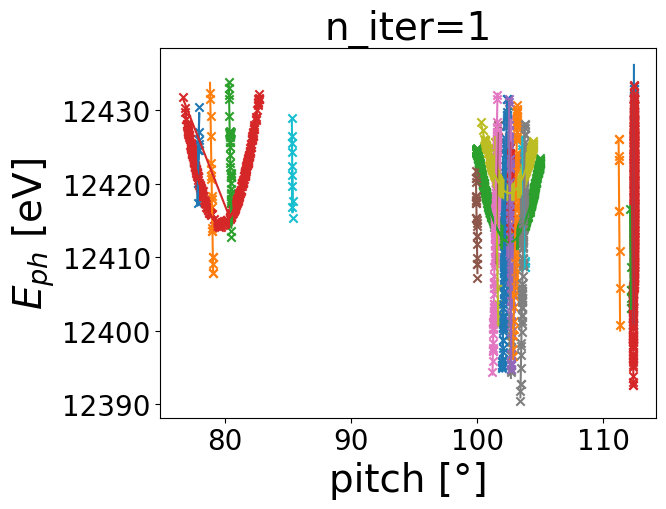

51
[ 1.15333221e+00  2.12894512e+00  7.54849739e-01 -1.59483526e-02
 -2.69419250e-03 -6.46557482e+00] 0.8101505287955544


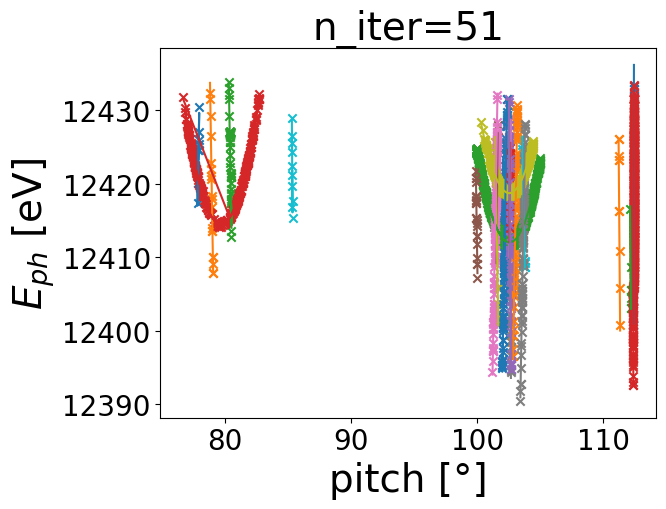

101
[ 1.15333221e+00  2.12894512e+00  7.54849739e-01 -1.59483526e-02
 -2.69419250e-03 -6.46557482e+00] 0.8101505287955544


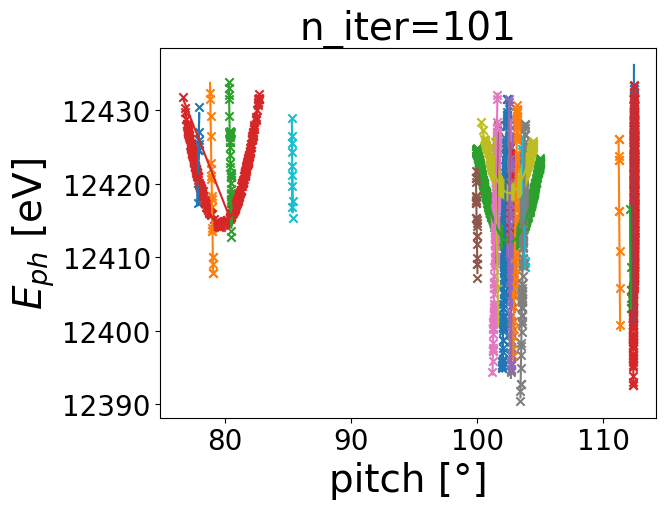

151
[ 1.15333221e+00  2.12894512e+00  7.54849739e-01 -1.59483526e-02
 -2.69419250e-03 -6.46557482e+00] 0.8101505287955544


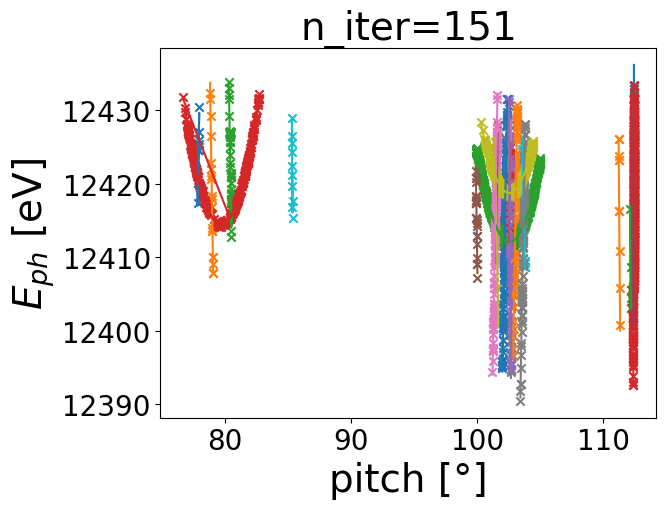

201
[ 1.15333220e+00  2.12894513e+00  7.54849894e-01 -1.59483499e-02
 -2.69419164e-03 -6.46557538e+00] 0.8101505287941373


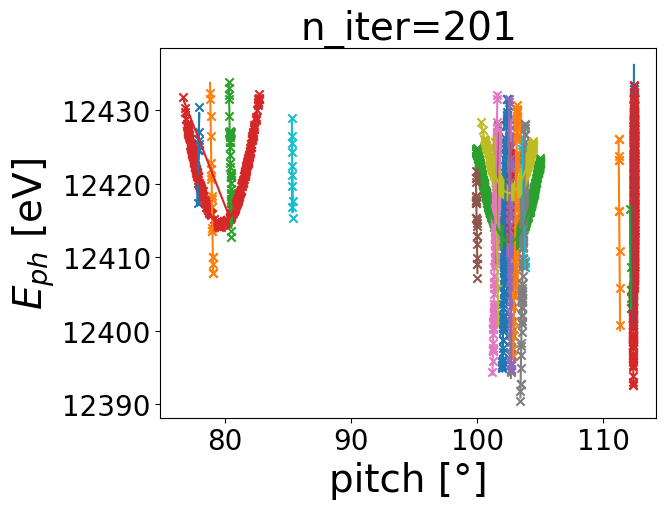

Optimization terminated successfully.
         Current function value: 0.810151
         Iterations: 231
         Function evaluations: 409
231
[ 1.15333221e+00  2.12894512e+00  7.54849699e-01 -1.59483533e-02
 -2.69419443e-03 -6.46557515e+00] 0.8101505287935917


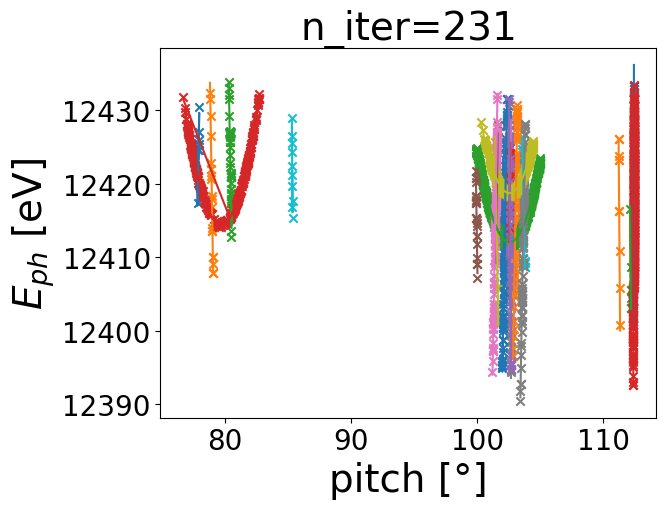

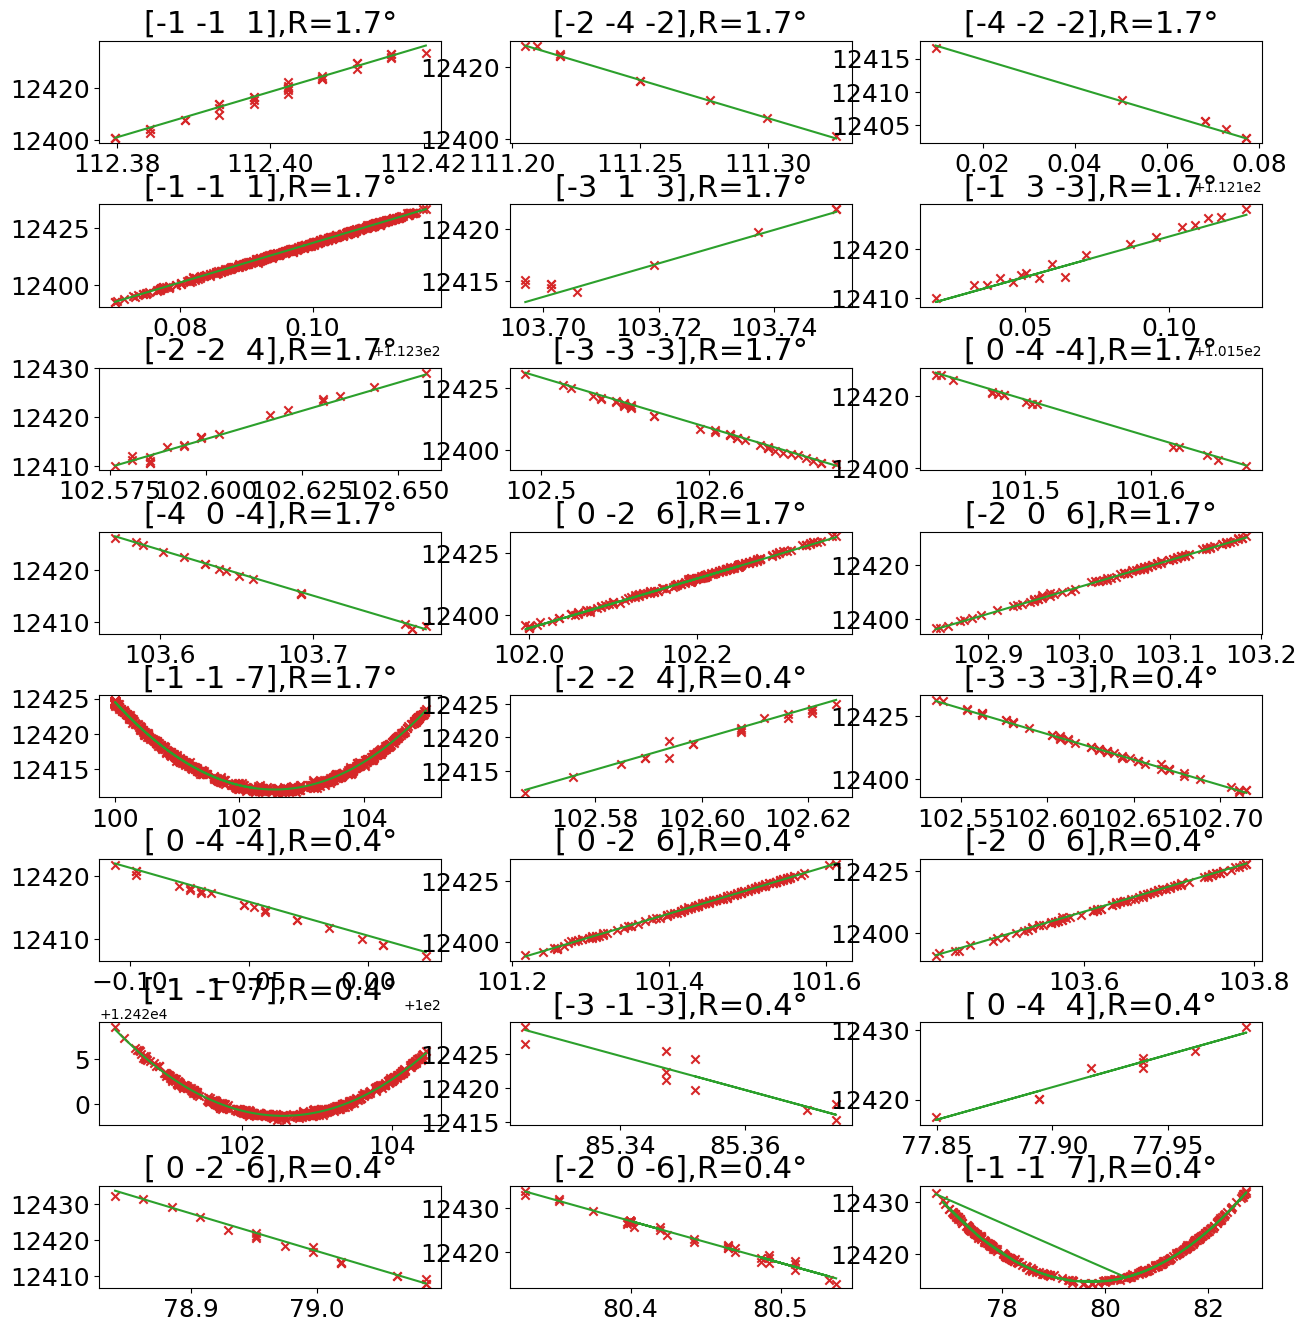

In [43]:
## do the fit including the HIREX dispersion as free parameter
Ecentral_orig = 12407
dEdP_orig = 0.15
#do the actual fit
def optFuncp_wdPR(dP,dR,dY,dPR,Ecorr,disp_HIREX):
    #peval = np.linspace(pitches.min(),pitches.max(),3001)
    cost = 0
    E_loc =  [(E_H-Ecentral_orig)*disp_HIREX/dEdP_orig + Ecentral_orig-Ecorr for E_H in E_H_acc]
    for Hidx, H in enumerate(Hquery_acc):
        lidx = HtoMeas_acc[Hidx]
        if lidx is not None:
            peval = np.array(pitch_acc[lidx])
            #if peval.size>0 :
            EBraggs,_ = HXRSS_singleLine(json.loads(H),peval,[roll_acc[lidx]],dP,dR,dY,dPR)
            EBraggs = np.array(EBraggs)
            cost += np.sum((EBraggs-E_loc[lidx])**2)/peval.size**2
    return 1/cost

def optFuncp_wdPR_d(dP,dR,dY,dPR,dPY,Ecorr,disp_HIREX=0.105):
    #peval = np.linspace(pitches.min(),pitches.max(),3001)
    cost = 0
    E_loc =  [(E_H-Ecentral_orig)*disp_HIREX/dEdP_orig + Ecentral_orig-Ecorr for E_H in E_H_acc]
    for Hidx, H in enumerate(Hqueryd_acc):
        lidx = HtoMeasd_acc[Hidx]
        if lidx is not None:
            peval = np.array(pitch_acc[lidx])
            #if peval.size>0 :
            # EBraggs,_ = HXRSS_singleLine(json.loads(H),peval,[roll_acc[lidx]],dP,dR,dY,dPR)
            EBraggs = HXRSS_singleLine_ddiff(H,peval,[roll_acc[lidx]],dP,dR,dY,dPR,dPY)
            EBraggs = np.asarray(EBraggs)
            cost += np.sum((EBraggs-E_loc[lidx])**2)/peval.size**2
    return 1/cost
  
def optFunc_minimizer(x):
    #return 1/optFuncp(x[0],x[1],x[2],0)
    return 1/optFuncp_wdPR_d(x[0],x[1],x[2],x[3],x[4],x[5])
def display_Func(intermediate_result):
    disp_HIREX = 0.105
    global forcePlot
    global niter
    niter += 1
    if(niter%50 == 1 or forcePlot):
        print(niter)
        print(intermediate_result.x,intermediate_result.fun)
        plt.title("n_iter="+str(niter),fontsize=28)
        #plt.scatter(pitches,Eph_seed,color='red',s=1)
        plt.ylabel("$E_{ph}$ [eV]",fontsize=28)
        plt.xlabel("pitch [°]", fontsize=28)
        plt.tick_params(labelsize=20)
        dP,dR,dY,dPR,dPY,Ecorr = intermediate_result.x
        E_loc =  [(E_H-Ecentral_orig)*disp_HIREX/dEdP_orig + Ecentral_orig - Ecorr for E_H in E_H_acc]

        #dP,dR,dY = intermediate_result.x
        for Hidx, H in enumerate(Hqueryd_acc):
            lidx = HtoMeasd_acc[Hidx]
            #print(lidx)
            #P0 = P0s[lidx]
            if lidx is not None:
                peval = pitch_acc[lidx]
                # if peval.size>0:
                #EBragg,_ = HXRSS_singleLine(json.loads(H),peval,[roll_acc[lidx]],dP,dR,dY,dPR)
                EBragg = HXRSS_singleLine_ddiff(H,peval,[roll_acc[lidx]],dP,dR,dY,dPR,dPY)
                EBragg = np.asarray(EBragg)

                #print(peval_sub.min(),peval_sub.max())
                plt.scatter(peval,E_loc[lidx],marker='x')
                plt.plot(peval,EBragg)
            #plt.ylim(Eph_seed.min(),Eph_seed.max())
        plt.show()

niter = 0
forcePlot = False
# x0 = [1.15497246, 0.61820617, -0.82300946,  0.01643269, -7.39200109, 0.10563662]
#x0 = np.array([dPguess, dRguess, dYguess, dRPguess, Ecorrguess,0.15])
#x0 = np.array([ 1.15497246, 0, 0,  0, -5.83095293e+00,0.10563662])
#x0 = np.array([1.16608634, -0.30329348, -0.04239605,  0.02686069, -7.44802075,  0.105])
#x0 = np.array([1.15032315,  1.28583585, -1.23740417,  0.00881059, -6.36851326, 0.10490858])
#x0 = np.array([1.15398699, 2.13210881, 0.71054749, -0.01682142,-0.01, -6.36836301])
#x0 = np.array([1.15398699, 2.13210881, 0.71054749, -0.00882142,0.005, -6.36836301])
#x0 = np.array([ 1.13618725, 1.23812696, -2.9850711, -0.02267183, -6.15565892,  0.105      ])
# x0 = np.array([ 1.136187250, 0.1, 0.1, -0.008,-0.005, -6.15565892    ])
# x0 = np.array([ 1.15387894,  2.09467029, -0.74434779, -0.008,        -0.005,       -6        ])
x0 = np.array([ 1.15333221e+00,  2.12894512e+00,  7.54849739e-01, -1.59483526e-02, -2.69419250e-03, -6.46557482e+00])
#x0 = np.array([0,  0, 0,  0.00881059, -6.36851326, 0.10490858])
bounds = ([-2,2],[-3,3],[-3,3],[-0.05,0.05],[-0.03,0.03],[-20,20])
res = opt.minimize(optFunc_minimizer, x0, method='Nelder-Mead',
               options={'xatol': 1e-8,'fatol': 1e-5, 'disp': True,'maxiter':1000},bounds=bounds,callback=display_Func)
forcePlot=True
display_Func(res)
dPconv,dRconv,dYconv,dRPconv,dYPconv,Ecorrconv = res.x
disp_Hirex = 0.105

nlines = len(Hquery_acc)
ncols = min(3,nlines)
nrows = -(nlines // -3)

withGuess = False
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,ncols*(5)+(ncols-1)*0.6),gridspec_kw={'hspace':0.6})

E_H_corr = [(E_H-Ecentral_orig)*disp_Hirex/dEdP_orig + Ecentral_orig - Ecorrconv for E_H in E_H_acc]

for i in range(nlines,axs.size):
    axs.flatten()[i].set_visible(False)
for Hidx,H in enumerate(Hqueryd_acc):
    lidx = HtoMeasd_acc[Hidx]
    ax = axs.flatten()[Hidx]
    ax.set_title(f"{H},R={roll_acc[lidx]:.1f}°",fontsize=22)
    ax.tick_params(labelsize=18)
    if lidx is not None:
        peval = pitch_acc[lidx]
        if peval.size>0:
            # EBragg,_ = HXRSS_singleLine(json.loads(H),peval,[roll_acc[lidx]],dPconv,dRconv,dYconv,dRPconv)
            EBragg = HXRSS_singleLine_ddiff(H,peval,[roll_acc[lidx]],dPconv,dRconv,dYconv,dRPconv,dYPconv)
            EBragg = np.asarray(EBragg)
            

    #print(peval_sub.min(),peval_sub.max())
            ax.scatter(peval,E_H_corr[lidx],marker='x',color='tab:red')
            ax.plot(peval,EBragg,color='tab:green')
            if withGuess:

                #EBragg_guess,_ = HXRSS_singleLine(json.loads(H),peval,[roll_acc[lidx]],dPguess,dRguess,dYguess,dRPguess)
                EBragg_guess = HXRSS_singleLine_ddiff(H,peval,[roll_acc[lidx]],dPguess,dRguess,dYguess,dRPguess)
                EBragg_guess = np.asarray(EBragg_guess) +Ecorrguess-Ecorrconv
                ax.plot(peval,EBragg_guess)

From -0.01
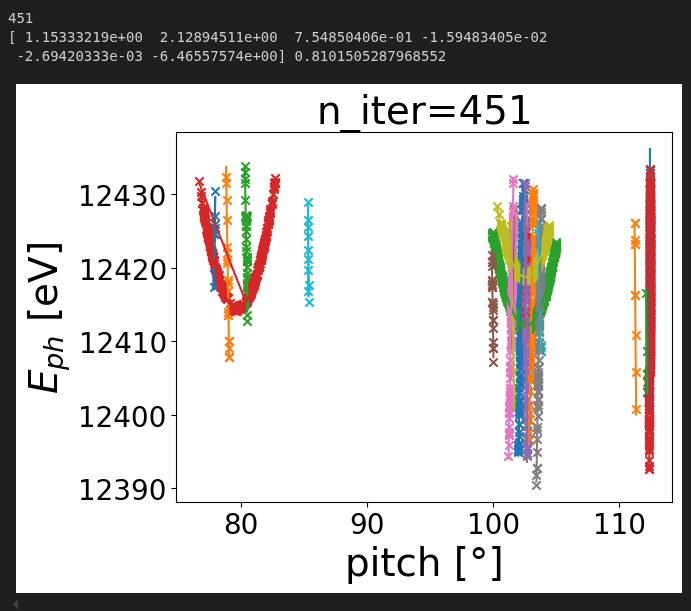